<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Decision tree to predict the Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Description of the problem
This dataset originally comes from the National Institute of Diabetes and Digestive and Kidney Diseases. The goal is to predict, based on diagnostic measures, whether or not a patient has diabetes.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Import libraries
</div>



In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

# Libraries for preprocessing and Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Configuración para visualización mejorada de DataFrames
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.width', None)        # Ancho automático
pd.set_option('display.max_colwidth', 100)  # Ancho máximo de columnas
pd.set_option('display.float_format', '{:.2f}'.format)  # Formato para flotantes

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


# Step 1: Loading the CSV into a python dataset

Load the datase and specify the target variable


</div>

In [3]:
# Se cargan los datos (usando sep=';' porque el archivo usa punto y coma como separador)
df = pd.read_csv('../data/raw/diabetes.csv', sep=',')
target_variable = 'Outcome'
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.90,0.17,63,0
764,2,122,70,27,0,36.80,0.34,27,0
765,5,121,72,23,112,26.20,0.24,30,0
766,1,126,60,0,0,30.10,0.35,47,1
767,1,93,70,31,0,30.40,0.32,23,0


In [5]:
df.shape

(768, 9)

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Missing Values Analysis

</div>

In [6]:
# Para las columnas de tipo object
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

✓ No missing values found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Detect the duplicates
</div>

In [8]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Option 1: Keep first occurrence
    print("\nOptions for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")



DUPLICATE ROWS DETECTION

Total duplicate rows: 0
Percentage of duplicates: 0.00%

✓ No duplicate rows found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Feature Type Identification
</div>

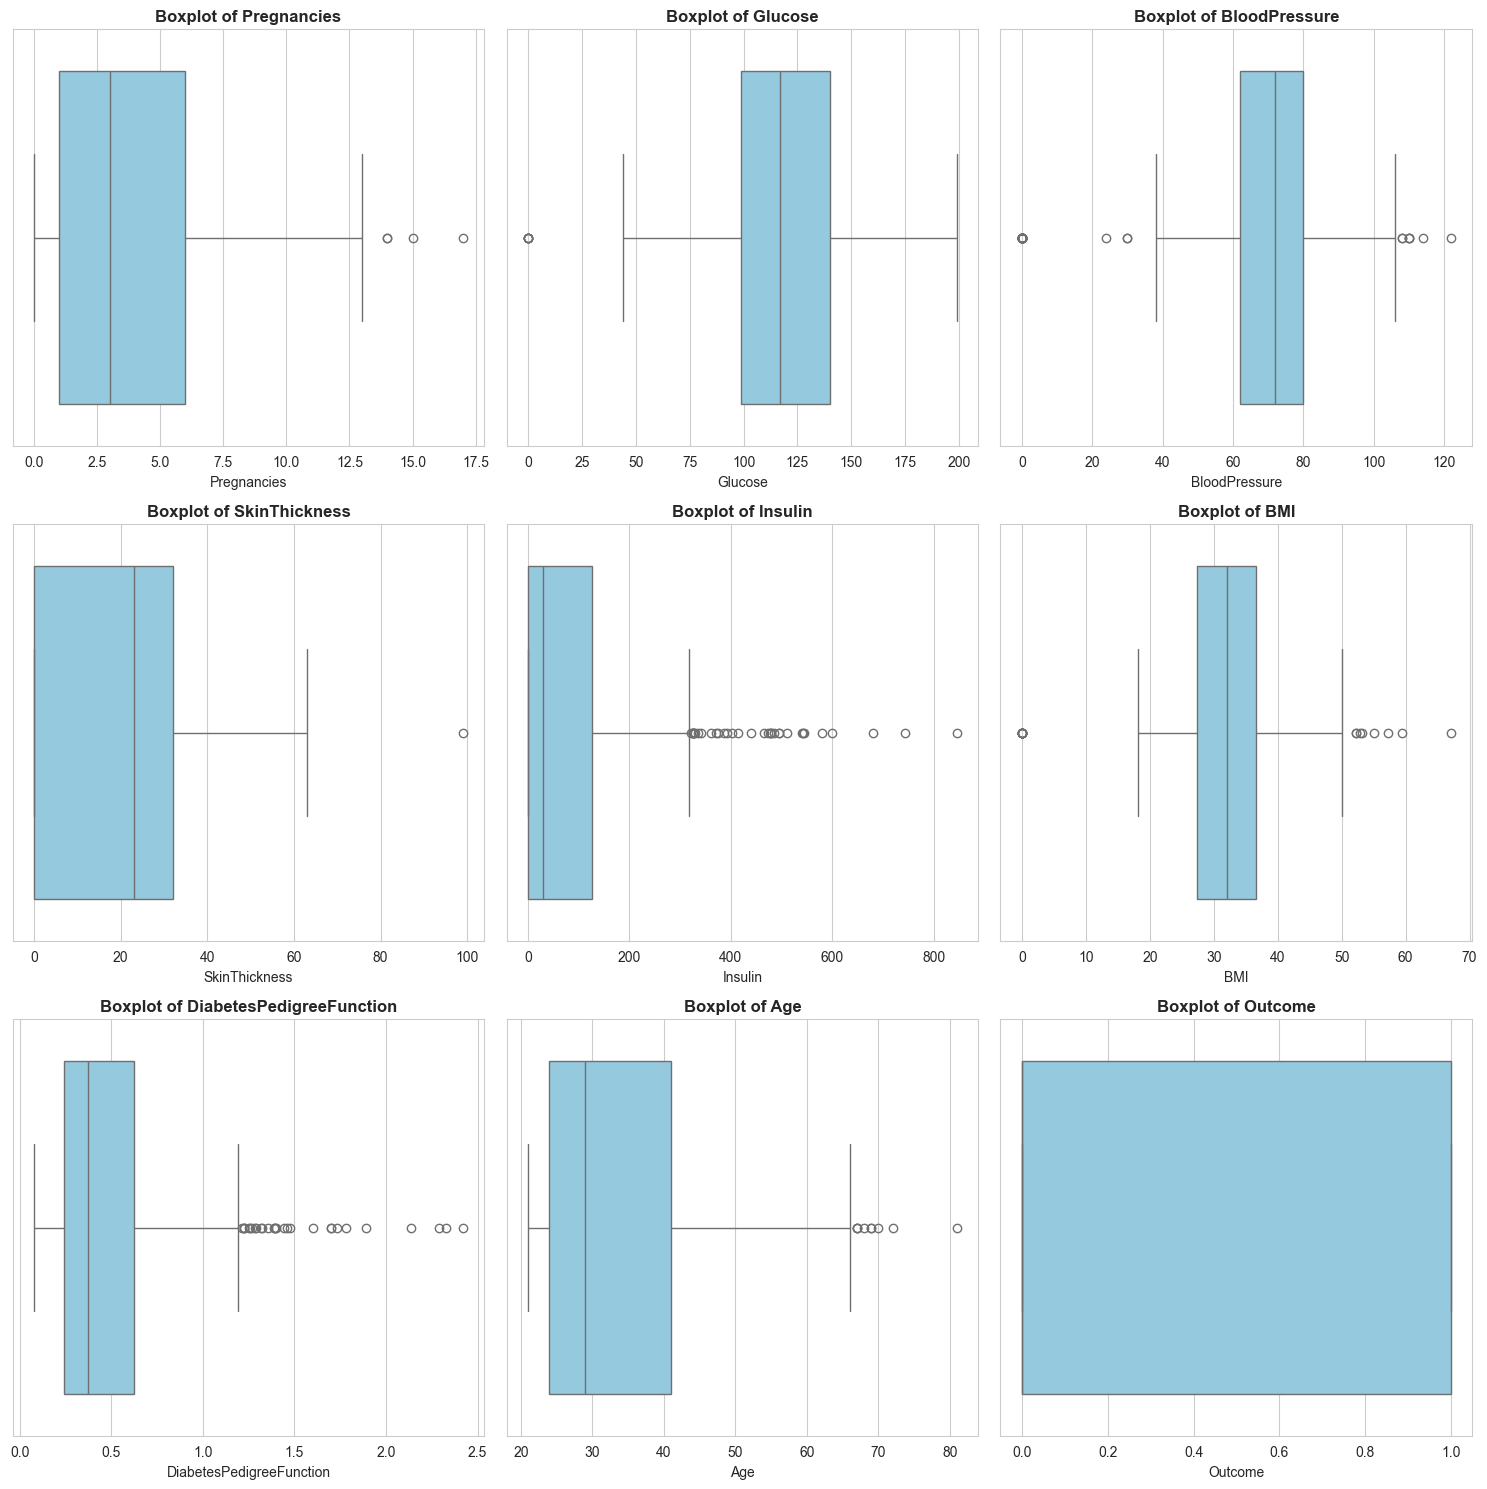

In [9]:
# Pasos para ver los outliers de cada variable numérica (3 gráficos por línea)
numeric_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Redondeo hacia arriba

# Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Analayze data

* The dataframe has 369 columns and 9 variables. 

* All columns are numeric

* There isn´t any null values

* There isn´t any duplicated rows

##### Columns:

- Pregnancies: Most women have 0-6 pregnancies, but outliers go up to 17. Right-skewed distribution

- Glucose: Few outliers on both ends. Relatively normal distribution

- Blood Pressure: Many outliers, especially high values

- Insulin: EXTREME outliers reaching 600-800 .Most values clustered low. Highly right-skewed


- BMI: Some high outliers (60-70) .Most values between 25-40 .Few extreme obesity cases. 

- SkinThickness: Moderate outliers. Relatively symmetric. 

- DiabetesPedigreeFunction: Many small outliers .Concentrated near 0-1


- Age: Few outliers. Uniform distribution. Range 21-80 years

- Outcome: Binary (0 or 1)
</div>


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Analyze the dataset

</div>

In [10]:
# Additional statistics: skewness and kurtosis
numeric_features= df.select_dtypes(include=[np.number]).columns

stats_df = pd.DataFrame({
    'Skewness': df[numeric_features].skew(),
    'Kurtosis': df[numeric_features].kurtosis()
})
print("\nSkewness and Kurtosis:")
display(stats_df)


Skewness and Kurtosis:


,Skewness,Kurtosis
Pregnancies,0.90,0.16
Glucose,0.17,0.64
BloodPressure,-1.84,5.18
SkinThickness,0.11,-0.52
Insulin,2.27,7.21
BMI,-0.43,3.29
DiabetesPedigreeFunction,1.92,5.59
Age,1.13,0.64
Outcome,0.64,-1.60


In [ ]:
# Automated Analysis of Skewness and Kurtosis
if numeric_features is not None:
    print("="*80)
    print("SKEWNESS AND KURTOSIS ANALYSIS")
    print("="*80)
    
    # Define interpretation functions
    def interpret_skewness(skew_value):
        """Interpret skewness value"""
        abs_skew = abs(skew_value)
        if abs_skew < 0.5:
            return "Fairly Symmetric-OK ", "No transformation needed"
        elif abs_skew < 1:
            return "Moderately Skewed- ALERT!! ", "Consider transformation (log, sqrt)"
        else:
            direction = "Right (positive)" if skew_value > 0 else "Left (negative)"
            return f"Highly Skewed ({direction}) ⚠⚠", "Transformation recommended (log, box-cox)"
    
    def interpret_kurtosis(kurt_value):
        """Interpret kurtosis value"""
        if abs(kurt_value) < 1:
            return "Normal Tails- OK ", "Distribution is close to normal"
        elif kurt_value > 3:
            return "Very Heavy Tails- ALERT!!", "Many outliers present"
        elif kurt_value > 1:
            return "Heavy Tails- ALERT!", "Some outliers present"
        else:
            return "Light Tails", "Fewer outliers than normal"
    
    # Analyze each feature
    transformation_needed = []
    
    for feature in numeric_features:
        skew_val = df[feature].skew()
        kurt_val = df[feature].kurtosis()
        
        skew_interp, skew_action = interpret_skewness(skew_val)
        kurt_interp, kurt_action = interpret_kurtosis(kurt_val)
        
        print(f"\n{feature}:")
        print(f"  Skewness: {skew_val:>7.3f}  → {skew_interp}")
        print(f"            Action: {skew_action}")
        print(f"  Kurtosis: {kurt_val:>7.3f}  → {kurt_interp}")
        print(f"            Action: {kurt_action}")
        
        # Track features needing transformation
        if abs(skew_val) >= 1 or kurt_val > 3:
            transformation_needed.append({
                'Feature': feature,
                'Skewness': skew_val,
                'Kurtosis': kurt_val,
                'Issue': []
            })
            if abs(skew_val) >= 1:
                transformation_needed[-1]['Issue'].append('High Skewness')
            if kurt_val > 3:
                transformation_needed[-1]['Issue'].append('Heavy Tails')
    
    # Summary and Recommendations
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    if transformation_needed:
        print(f"\n⚠ {len(transformation_needed)} feature(s) may benefit from transformation:\n")
        
        for item in transformation_needed:
            print(f"• {item['Feature']}")
            print(f"  Issues: {', '.join(item['Issue'])}")
            print(f"  Suggested transformations:")
            
            # Recommend specific transformations
            if item['Skewness'] > 1:
                print(f"    - Log transformation: np.log1p(df['{item['Feature']}'])")
                print(f"    - Square root: np.sqrt(df['{item['Feature']}'])")
            elif item['Skewness'] < -1:
                print(f"    - Square: df['{item['Feature']}']**2")
                print(f"    - Exponential: np.exp(df['{item['Feature']}'])")
            
            if item['Kurtosis'] > 3:
                print(f"    - Consider outlier treatment before transformation")
            print()
        
        print("Next Steps:")
        print("   1. Investigate outliers in features with high kurtosis")
        print("   2. For decision trees don´t need to apply transformations to highly skewed features")
        
    else:
        print("\n✓ All numeric features have acceptable skewness and kurtosis!")
        print("  No transformations required for distribution normality.")
    
    print("\n" + "="*80)
else:
    print("No numeric features to analyze.")

SKEWNESS AND KURTOSIS ANALYSIS

Pregnancies:
  Skewness:   0.902  → Moderately Skewed- ALERT!! 
            Action: Consider transformation (log, sqrt)
  Kurtosis:   0.159  → Normal Tails- OK 
            Action: Distribution is close to normal

Glucose:
  Skewness:   0.174  → Fairly Symmetric-OK 
            Action: No transformation needed
  Kurtosis:   0.641  → Normal Tails- OK 
            Action: Distribution is close to normal

BloodPressure:
  Skewness:  -1.844  → Highly Skewed (Left (negative)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:   5.180  → Very Heavy Tails- ALERT!!
            Action: Many outliers present

SkinThickness:
  Skewness:   0.109  → Fairly Symmetric-OK 
            Action: No transformation needed
  Kurtosis:  -0.520  → Normal Tails- OK 
            Action: Distribution is close to normal

Insulin:
  Skewness:   2.272  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurto

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Target Variable Analysis

Understanding the target variable is important for Decision Tree. We'll check:
- Class imbalance detection
- Baseline perfomance.
- Metric seleccion - if the dataset is imbalanced, accuracy is not a good metric. We should use precision, recall or F1-score.

</div>

In [12]:
# Target variable statistics
target_column='Outcome'
target_data = df[target_column]

print(f"Target Variable: {target_column}")
print("="*60)
print(f"Mean: {target_data.mean():.2f}")
print(f"Median: {target_data.median():.2f}")
print(f"Std Dev: {target_data.std():.2f}")
print(f"Min: {target_data.min():.2f}")
print(f"Max: {target_data.max():.2f}")
print(f"Range: {target_data.max() - target_data.min():.2f}")
print(f"\nSkewness: {target_data.skew():.2f}")
print(f"Kurtosis: {target_data.kurtosis():.2f}")

# Normality test
print("\nNormality Tests:")
_, shapiro_p = shapiro(target_data.dropna())
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
print(f"Is Normal (p > 0.05)? {shapiro_p > 0.05}")

Target Variable: Outcome
Mean: 0.35
Median: 0.00
Std Dev: 0.48
Min: 0.00
Max: 1.00
Range: 1.00

Skewness: 0.64
Kurtosis: -1.60

Normality Tests:
Shapiro-Wilk p-value: 0.0000
Is Normal (p > 0.05)? False


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


#### Basic Statistics
Mean: 0.35 → 35% of patients in the dataset have diabetes (Outcome=1), while 65% don't (Outcome=0)

Median: 0.00 → More than half of the patients are non-diabetic (confirms class imbalance)

Min/Max: 0.00/1.00 → Binary variable (0 = No Diabetes, 1 = Has Diabetes)


#### Distribution Shape
Skewness: 0.64 → Moderately right-skewed (longer tail on the right)

Distribution is asymmetric, leaning toward 0

Kurtosis: -1.60 → Platykurtic (flatter than normal distribution)

#### Normality Test

Shapiro-Wilk p-value: 0.0000 → p < 0.05 means reject normality

Not normal

##### Key Insights:

Class Imbalance: You have a 65:35 ratio (non-diabetic:diabetic)

Not severely imbalanced, but worth noting

Decision Trees don't require normally distributed targets

This distribution is perfectly fine

The model will learn to classify these two classes

Consider using stratify=y in your train_test_split to maintain this ratio

</div>

Text(0.5, 1.0, 'Diabetes Proportion')

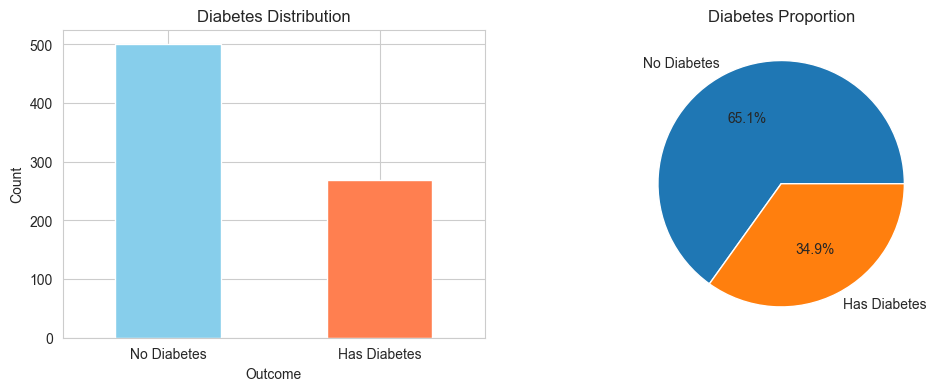

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart (better than histogram for categorical)
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Diabetes Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_xticklabels(['No Diabetes', 'Has Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   labels=['No Diabetes', 'Has Diabetes'])
axes[1].set_ylabel('')
axes[1].set_title('Diabetes Proportion')

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Correlation Analysis

Correlation analysis helps identify:
- Features strongly related to the target
- Multicollinearity between features

</div

In [14]:
# Correlation matrix
correlation_matrix = df[numeric_features].corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00


In [15]:
# Correlation with target variable
correlations = correlation_matrix[target_column].sort_values(ascending=False)
print(f"\nCorrelation with {target_column}:")
print(correlations)


Correlation with Outcome:
Outcome                    1.00
Glucose                    0.47
BMI                        0.29
Age                        0.24
Pregnancies                0.22
DiabetesPedigreeFunction   0.17
Insulin                    0.13
SkinThickness              0.07
BloodPressure              0.07
Name: Outcome, dtype: float64


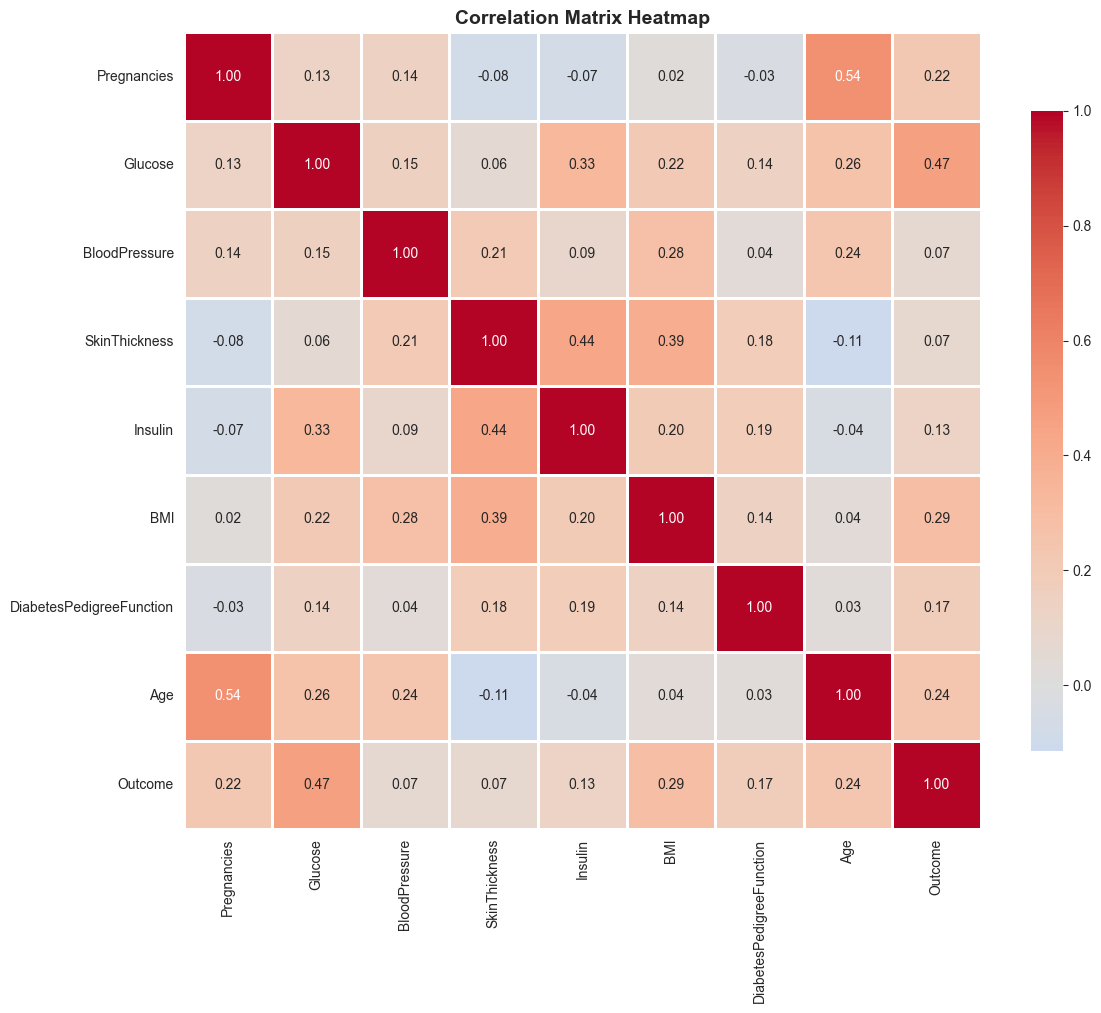


Identify strong correlations (|r| > 0.7)


In [16]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

There isn´t strong correlation between features and the target variable, which is common in medical datasets. This suggests that no single feature dominates the prediction, and the model will need to learn complex interactions between features to predict diabetes effectively.

</div>

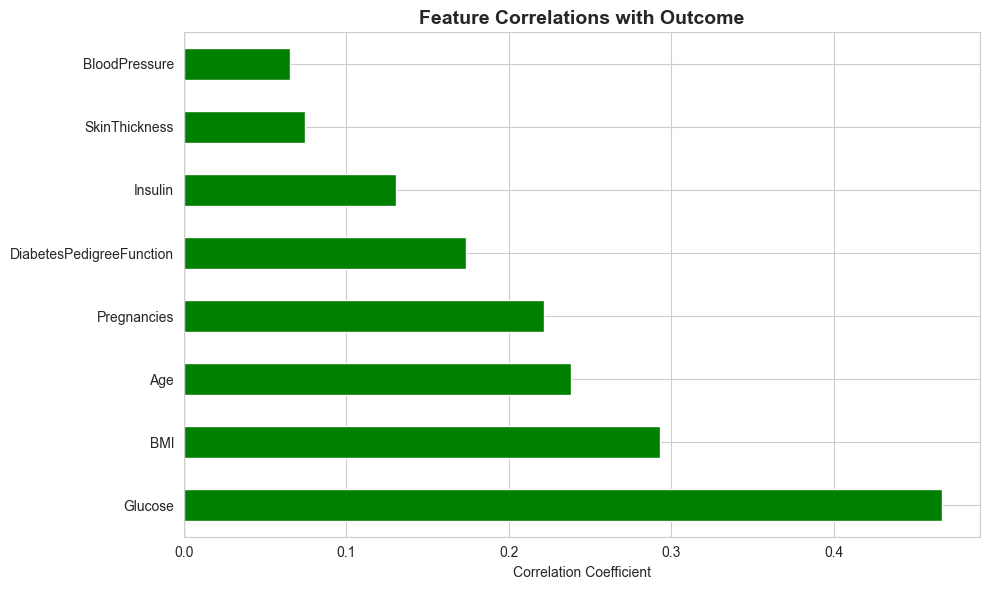

In [17]:
# Bar plot of correlations with target
target_corr = correlations[correlations.index != target_column]

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title(f'Feature Correlations with {target_column}', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Outlier Detection

Outliers can significantly affect Linear Regression models. We'll use the IQR (Interquartile Range) method.
</div>

In [18]:
# Detect outliers using IQR method
outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

if outlier_summary:
    print("Outliers detected:")
    print("="*60)
    for col, info in outlier_summary.items():
        print(f"\n{col}:")
        print(f"  Count: {info['count']} ({info['percentage']:.2f}%)")
        print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
else:
    print("✓ No outliers detected using IQR method!")

Outliers detected:

Pregnancies:
  Count: 4 (0.52%)
  Bounds: [-6.50, 13.50]

Glucose:
  Count: 5 (0.65%)
  Bounds: [37.12, 202.12]

BloodPressure:
  Count: 45 (5.86%)
  Bounds: [35.00, 107.00]

SkinThickness:
  Count: 1 (0.13%)
  Bounds: [-48.00, 80.00]

Insulin:
  Count: 34 (4.43%)
  Bounds: [-190.88, 318.12]

BMI:
  Count: 19 (2.47%)
  Bounds: [13.35, 50.55]

DiabetesPedigreeFunction:
  Count: 29 (3.78%)
  Bounds: [-0.33, 1.20]

Age:
  Count: 9 (1.17%)
  Bounds: [-1.50, 66.50]


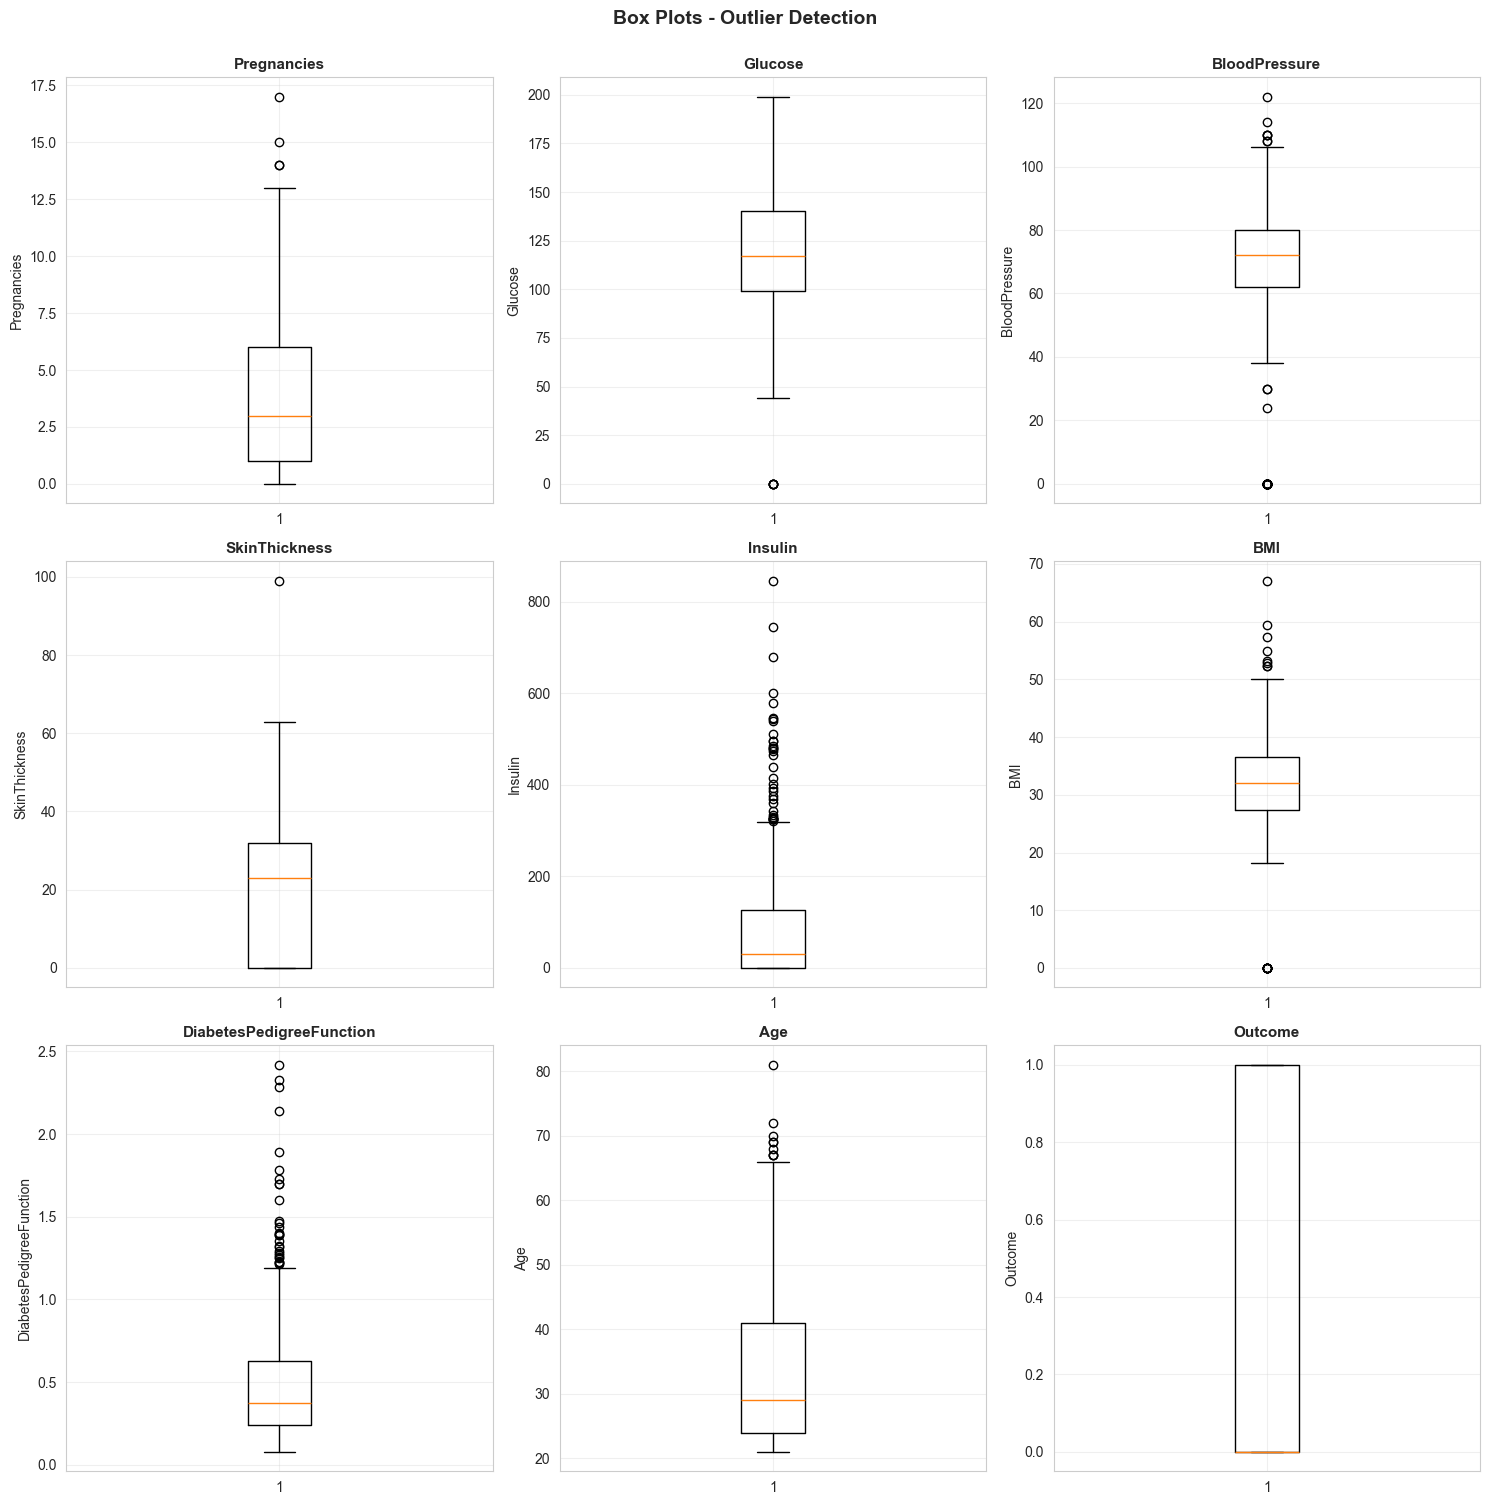

In [19]:
# Visualize outliers with box plots
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

For Decision tree, we don´t need to remove outliers, because they are not affected by them.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature Distributions

Visualizing distributions helps identify skewness and potential transformations needed.

</div>

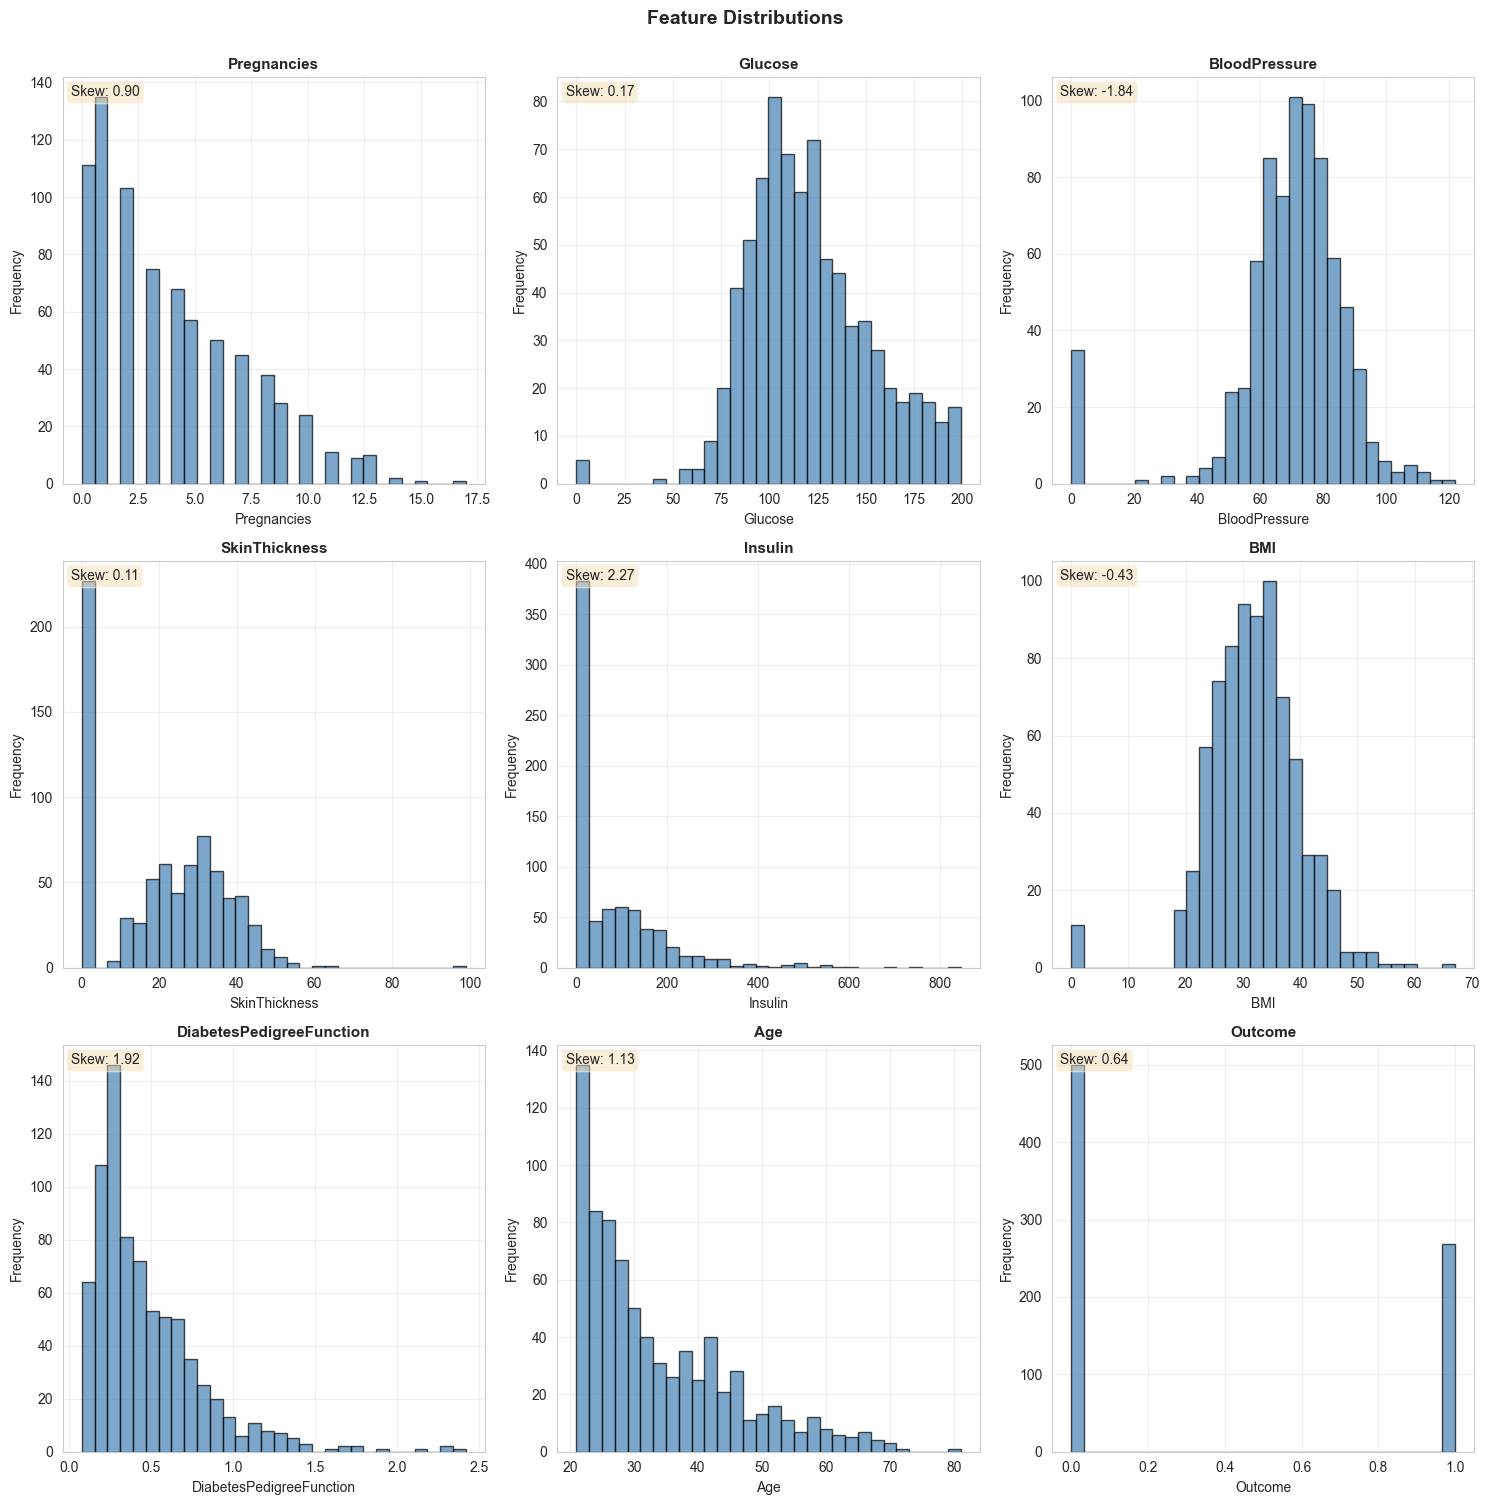

In [20]:
# Histogram for all numeric features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skewness = df[col].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature vs Target Relationships

Scatter plots help visualize the relationship between each feature and the target variable.
</div>

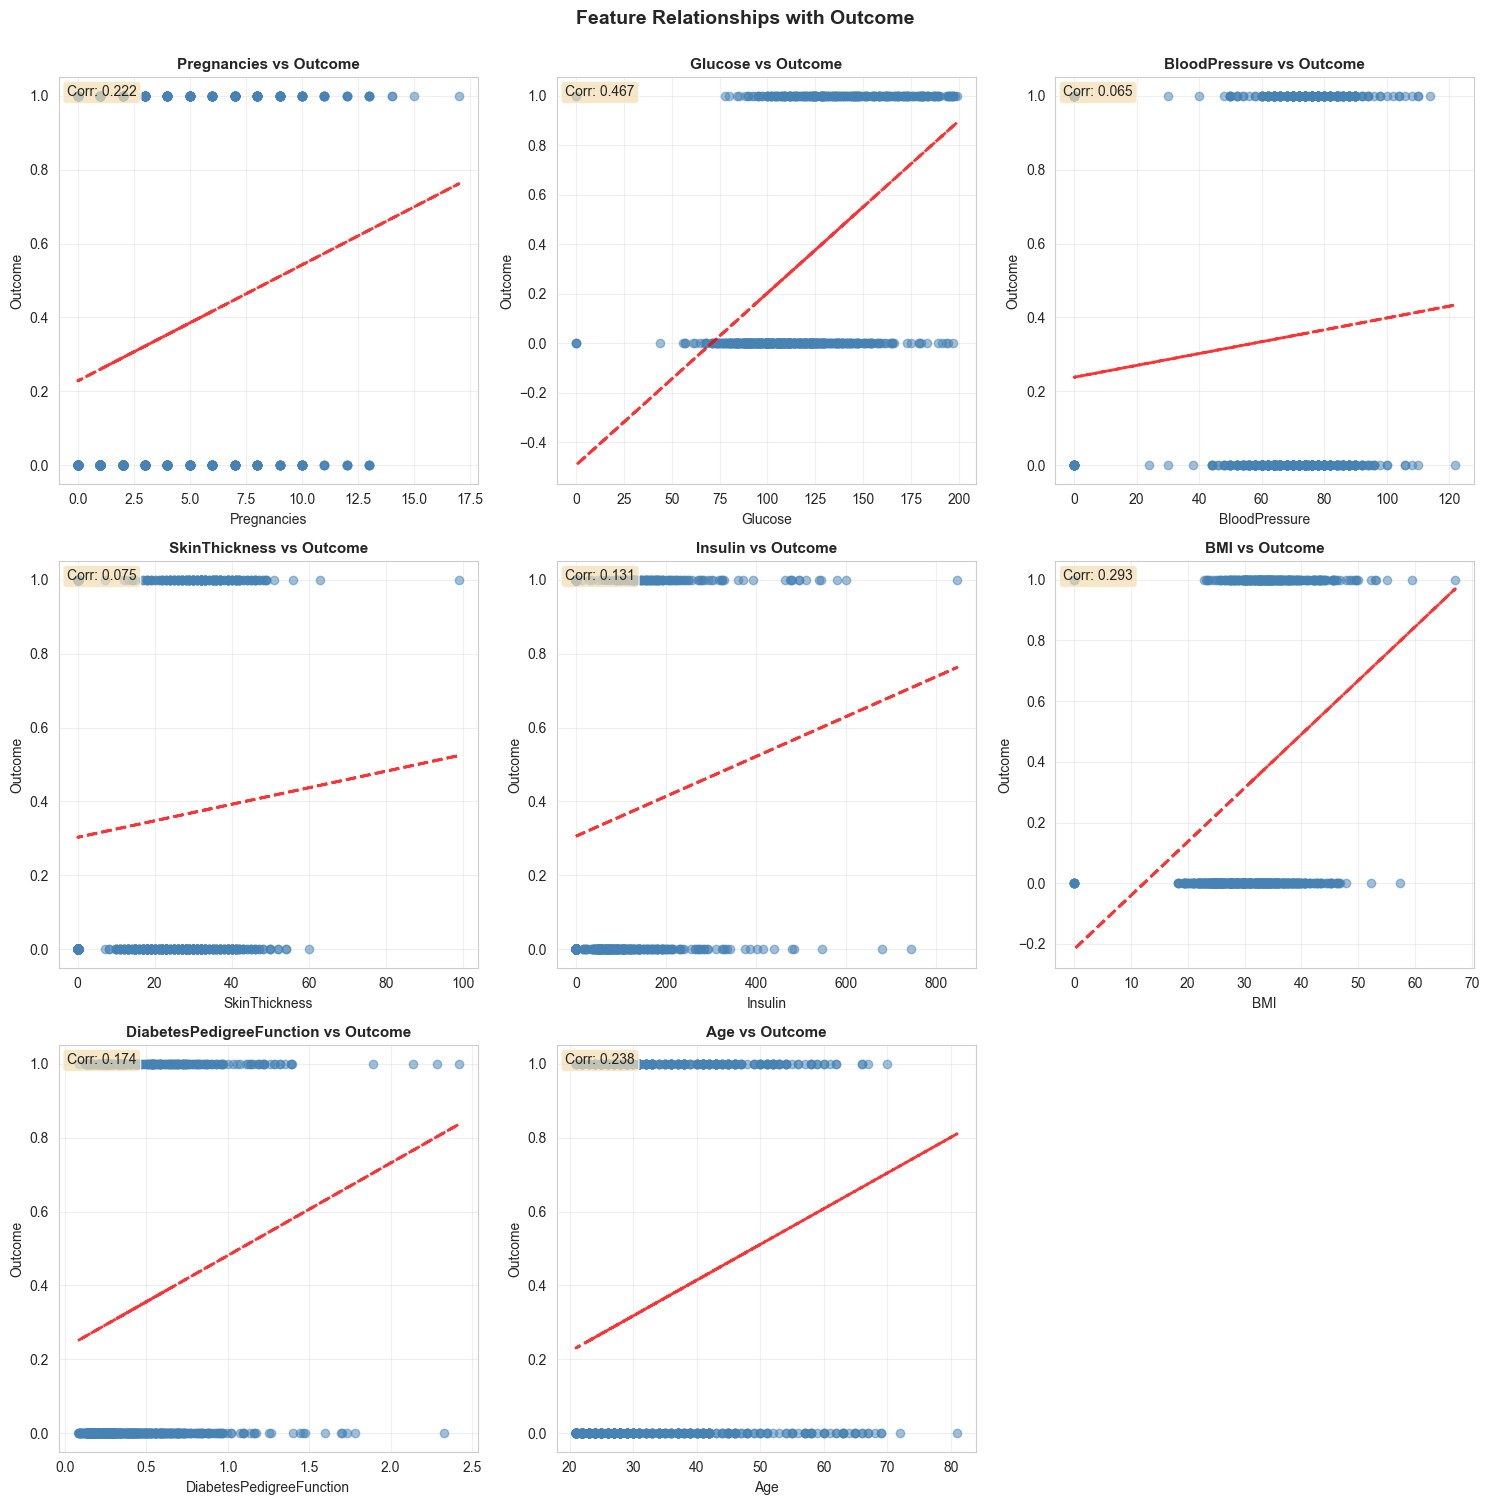

In [21]:
# Scatter plots: Features vs Target
features_to_plot = [f for f in numeric_features if f != target_column]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(features_to_plot):
    # Scatter plot
    axes[idx].scatter(df[col], df[target_column], alpha=0.5, color='steelblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel(target_column, fontsize=10)
    axes[idx].set_title(f'{col} vs {target_column}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line
    try:
        z = np.polyfit(df[col].dropna(), df[target_column].loc[df[col].dropna().index], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[col], p(df[col]), "r--", alpha=0.8, linewidth=2, label='Trend')
        
        # Add correlation coefficient
        corr = df[col].corr(df[target_column])
        axes[idx].text(0.02, 0.98, f'Corr: {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    except:
        pass

# Hide empty subplots
for idx in range(len(features_to_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Relationships with {target_column}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Pairplot (Relationships Overview)

Visualize all pairwise relationships at once.

</div>

Creating pairplot for: ['Outcome', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']


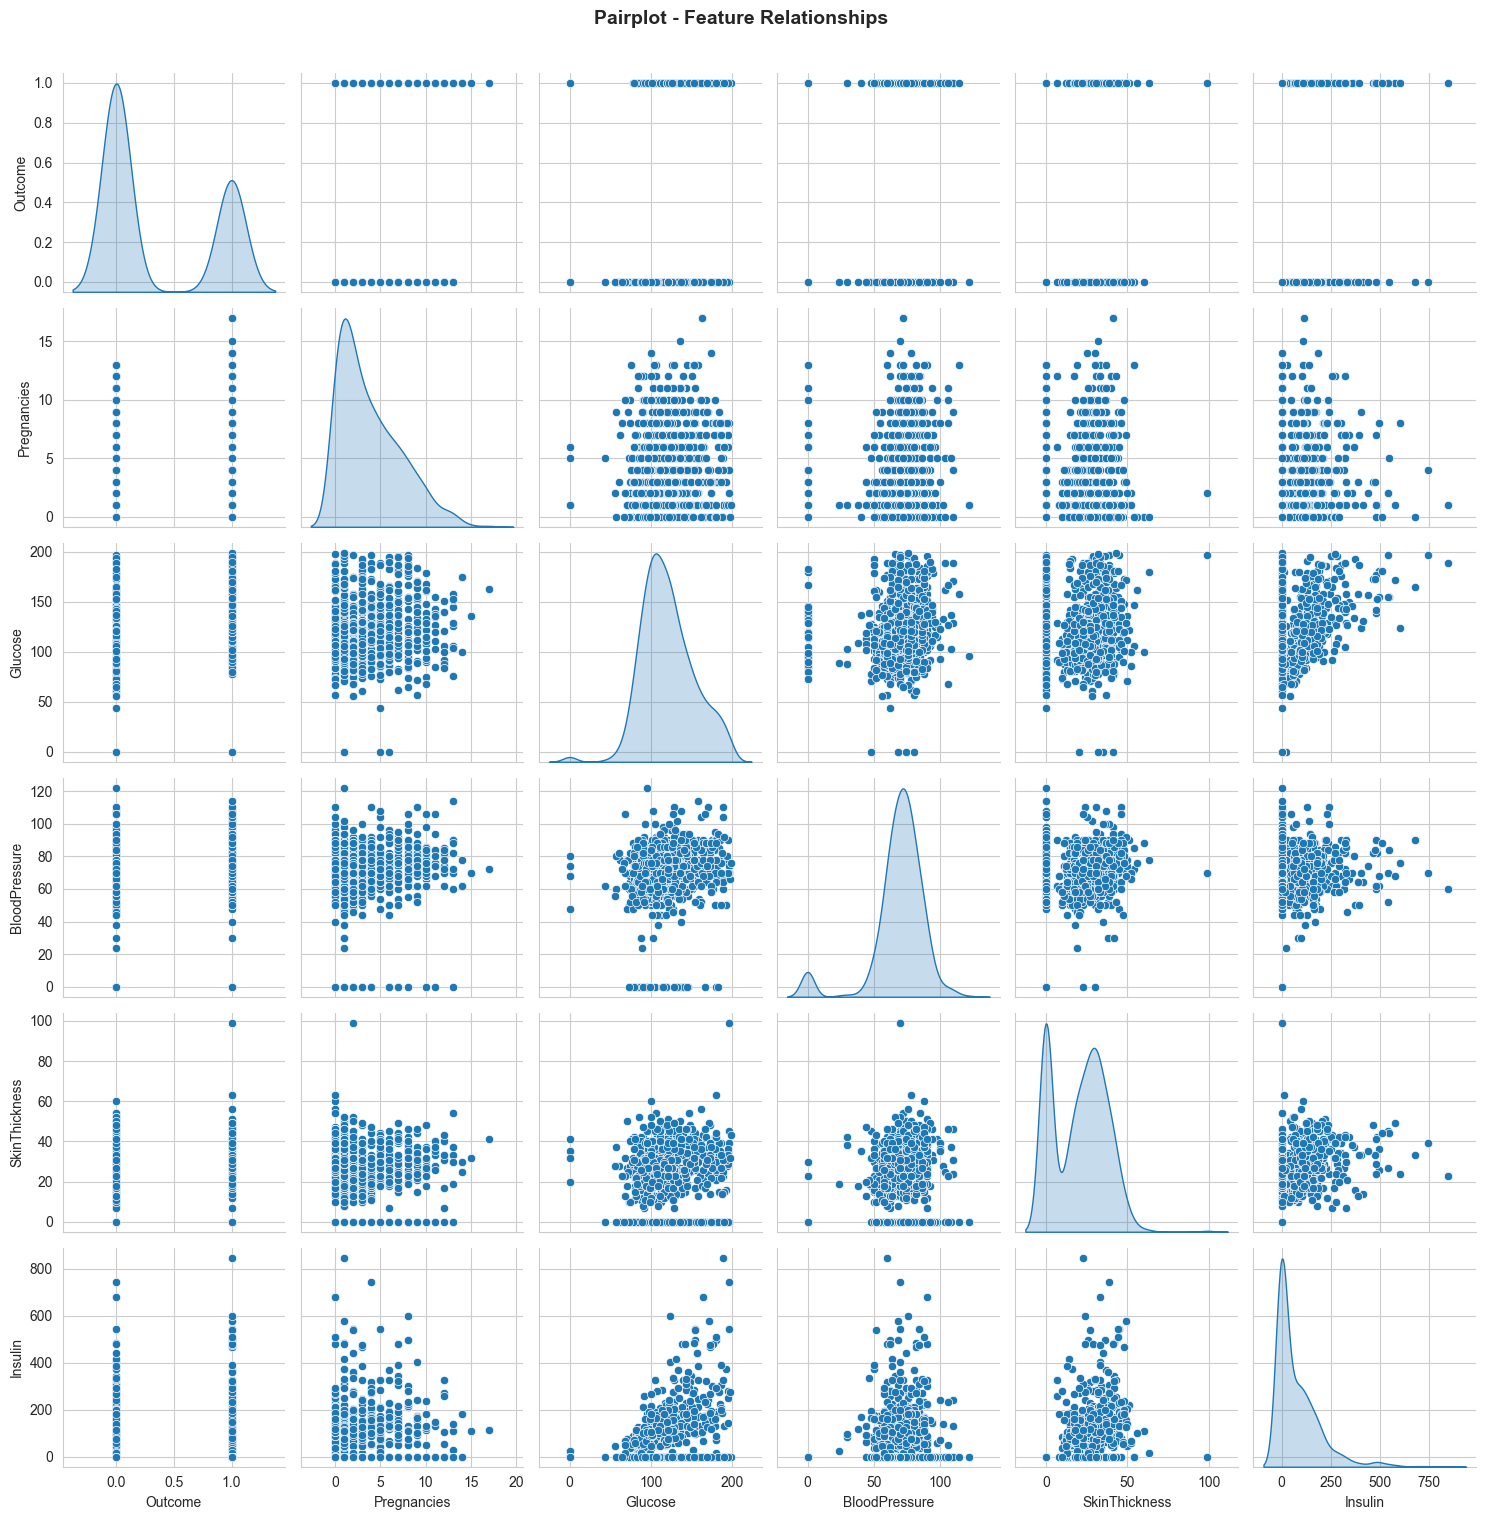

In [22]:
# Pairplot for numeric features (limit to avoid overcrowding)
features_for_pairplot = numeric_features[:6] if len(numeric_features) > 6 else numeric_features

if target_column not in features_for_pairplot:
    features_for_pairplot = [target_column] + [f for f in features_for_pairplot if f != target_column][:5]

print(f"Creating pairplot for: {features_for_pairplot}")
sns.pairplot(df[features_for_pairplot], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Pairplot Interpretation - Diabetes Dataset

This pairplot reveals several important insights about your data:

1. **Diagonal (Variable Distributions)**
   - **BloodPressure**: Normal-ish with spike near 0 - Zero values = missing data!
   - **SkinThickness**: Massive spike at 0, then spread - Many zeros = missing data!
   - **Insulin**: HUGE spike at 0, long right tail - Many zeros = missing data!

</div>

In [23]:
# 1. Handle missing data (zeros)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Check how many zeros
for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df)*100:.1f}%)")



Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


SkinThickness, Insulin, BMI needs to be impute with median
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 4. Data Preprocessing and Traininig with Decision Tree

### Handle Missing Values

</div>

In [24]:
# Create a copy of the original dataset
df_processed = df.copy()

print("="*70)
print("DATA PREPROCESSING PIPELINE")
print("="*70)

# Step 1: Identify columns with zero values that represent missing data
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nStep 1: Checking zero values (missing data)")
print("-"*70)
for col in cols_to_impute:
    zero_count = (df_processed[col] == 0).sum()
    zero_pct = (zero_count / len(df_processed)) * 100
    print(f"   {col:20} {zero_count:4} zeros ({zero_pct:5.1f}%)")

# Step 2: Replace zeros with NaN
print("\nStep 2: Replacing zeros with NaN")
print("-"*70)
for col in cols_to_impute:
    df_processed[col] = df_processed[col].replace(0, np.nan)
    nan_count = df_processed[col].isnull().sum()
    print(f"   {col:20} {nan_count:4} NaN values")

print(f"\n✓ Total rows with any missing values: {df_processed.isnull().any(axis=1).sum()}")
print(f"✓ Dataset shape: {df_processed.shape}")

DATA PREPROCESSING PIPELINE

Step 1: Checking zero values (missing data)
----------------------------------------------------------------------
   Glucose                 5 zeros (  0.7%)
   BloodPressure          35 zeros (  4.6%)
   SkinThickness         227 zeros ( 29.6%)
   Insulin               374 zeros ( 48.7%)
   BMI                    11 zeros (  1.4%)

Step 2: Replacing zeros with NaN
----------------------------------------------------------------------
   Glucose                 5 NaN values
   BloodPressure          35 NaN values
   SkinThickness         227 NaN values
   Insulin               374 NaN values
   BMI                    11 NaN values

✓ Total rows with any missing values: 376
✓ Dataset shape: (768, 9)


In [25]:
# Step 3: Impute missing values with median
print("\n" + "="*70)
print("IMPUTATION STRATEGY: MEDIAN")
print("="*70)

# Calculate and display medians BEFORE imputation (excluding NaN)
print("\nMedian values used for imputation:")
print("-"*70)
medians = {}
for col in cols_to_impute:
    median_value = df_processed[col].median()
    medians[col] = median_value
    print(f"   {col:20} Median = {median_value:.2f}")

# Perform imputation
imputer = SimpleImputer(strategy='median')
df_processed[cols_to_impute] = imputer.fit_transform(df_processed[cols_to_impute])

# Verify no missing values remain
print("\nVerification after imputation:")
print("-"*70)
missing_after = df_processed.isnull().sum().sum()
print(f"   Total missing values: {missing_after}")
if missing_after == 0:
    print("   ✓ All missing values successfully imputed!")
else:
    print(f"   ⚠ Warning: {missing_after} missing values still remain")

# Display summary statistics after imputation
print("\n📈 Dataset summary after preprocessing:")
print("-"*70)
print(f"   Total rows: {len(df_processed)}")
print(f"   Total columns: {len(df_processed.columns)}")
print(f"   Features: {len(df_processed.columns) - 1}")  # Excluding target
print(f"   Target: {target_column}")


IMPUTATION STRATEGY: MEDIAN

Median values used for imputation:
----------------------------------------------------------------------
   Glucose              Median = 117.00
   BloodPressure        Median = 72.00
   SkinThickness        Median = 29.00
   Insulin              Median = 125.00
   BMI                  Median = 32.30

Verification after imputation:
----------------------------------------------------------------------
   Total missing values: 0
   ✓ All missing values successfully imputed!

📈 Dataset summary after preprocessing:
----------------------------------------------------------------------
   Total rows: 768
   Total columns: 9
   Features: 8
   Target: Outcome


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Train-Test Split

Split the data into training and testing sets while maintaining class distribution.

</div>

In [ ]:
# Separate features and target
X = df_processed.drop(target_column, axis=1)
y = df_processed[target_column]

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

print(f"\nOriginal dataset:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"\n   Target distribution:")
print(f"   - Class 0 (No Diabetes): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
print(f"   - Class 1 (Has Diabetes): {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)")

# Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintains class distribution
)

print(f"\nAfter split (80% train, 20% test):")
print("-"*70)
print(f"\n   Training set:")
print(f"   - Size: {X_train.shape[0]} samples")
print(f"   - Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"   - Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\n   Testing set:")
print(f"   - Size: {X_test.shape[0]} samples")
print(f"   - Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   - Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print("\n✓ Data split complete with stratification!")

TRAIN-TEST SPLIT

📊 Original dataset:
   Features (X): (768, 8)
   Target (y): (768,)

   Target distribution:
   - Class 0 (No Diabetes): 500 (65.1%)
   - Class 1 (Has Diabetes): 268 (34.9%)

📊 After split (80% train, 20% test):
----------------------------------------------------------------------

   Training set:
   - Size: 614 samples
   - Class 0: 400 (65.1%)
   - Class 1: 214 (34.9%)

   Testing set:
   - Size: 154 samples
   - Class 0: 100 (64.9%)
   - Class 1: 54 (35.1%)

✓ Data split complete with stratification!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Build Baseline Decision Tree Model

Train an initial Decision Tree with default parameters.

</div>

In [27]:
# Create and train baseline Decision Tree
print("="*70)
print("BASELINE DECISION TREE MODEL")
print("="*70)

# Initialize model
dt_baseline = DecisionTreeClassifier(random_state=42)

# Train model
print("\nTraining baseline model...")
dt_baseline.fit(X_train, y_train)
print("✓ Training complete!")

# Display model parameters
print(f"\nModel Parameters:")
print("-"*70)
print(f"   Criterion: {dt_baseline.criterion}")
print(f"   Splitter: {dt_baseline.splitter}")
print(f"   Max Depth: {dt_baseline.max_depth if dt_baseline.max_depth else 'Unlimited'}")
print(f"   Min Samples Split: {dt_baseline.min_samples_split}")
print(f"   Min Samples Leaf: {dt_baseline.min_samples_leaf}")

# Tree complexity
print(f"\nTree Complexity:")
print("-"*70)
print(f"   Tree Depth: {dt_baseline.get_depth()}")
print(f"   Number of Leaves: {dt_baseline.get_n_leaves()}")
print(f"   Total Nodes: {dt_baseline.tree_.node_count}")

BASELINE DECISION TREE MODEL

Training baseline model...
✓ Training complete!

Model Parameters:
----------------------------------------------------------------------
   Criterion: gini
   Splitter: best
   Max Depth: Unlimited
   Min Samples Split: 2
   Min Samples Leaf: 1

Tree Complexity:
----------------------------------------------------------------------
   Tree Depth: 14
   Number of Leaves: 111
   Total Nodes: 221


In [28]:
# Make predictions
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Get probability predictions for ROC curve
y_train_pred_proba = dt_baseline.predict_proba(X_train)[:, 1]
y_test_pred_proba = dt_baseline.predict_proba(X_test)[:, 1]

print("✓ Predictions generated successfully!")

✓ Predictions generated successfully!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Evaluate Baseline Model

</div>

In [29]:
# Evaluate model performance
print("="*70)
print("BASELINE MODEL EVALUATION")
print("="*70)

# Training set performance
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("\nTraining Set Performance:")
print("-"*70)
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1-Score:  {train_f1:.4f}")

# Testing set performance
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTesting Set Performance:")
print("-"*70)
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")

# Check for overfitting
print("\nOverfitting Analysis:")
print("-"*70)
accuracy_diff = train_accuracy - test_accuracy
print(f"   Training Accuracy: {train_accuracy:.4f}")
print(f"   Testing Accuracy:  {test_accuracy:.4f}")
print(f"   Difference:        {accuracy_diff:.4f}")

if accuracy_diff > 0.1:
    print("Warning: Potential overfitting detected!")
    print("Consider pruning the tree or using cross-validation")
elif accuracy_diff > 0.05:
    print("Moderate overfitting detected")
    print("Model performs better on training data")
else:
    print("Good generalization - no significant overfitting!")

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred, 
                                   target_names=['No Diabetes', 'Has Diabetes']))

BASELINE MODEL EVALUATION

Training Set Performance:
----------------------------------------------------------------------
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

Testing Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.6818
   Precision: 0.5532
   Recall:    0.4815
   F1-Score:  0.5149

Overfitting Analysis:
----------------------------------------------------------------------
   Training Accuracy: 1.0000
   Testing Accuracy:  0.6818
   Difference:        0.3182
Consider pruning the tree or using cross-validation

DETAILED CLASSIFICATION REPORT (Test Set)

               precision    recall  f1-score   support

 No Diabetes       0.74      0.79      0.76       100
Has Diabetes       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



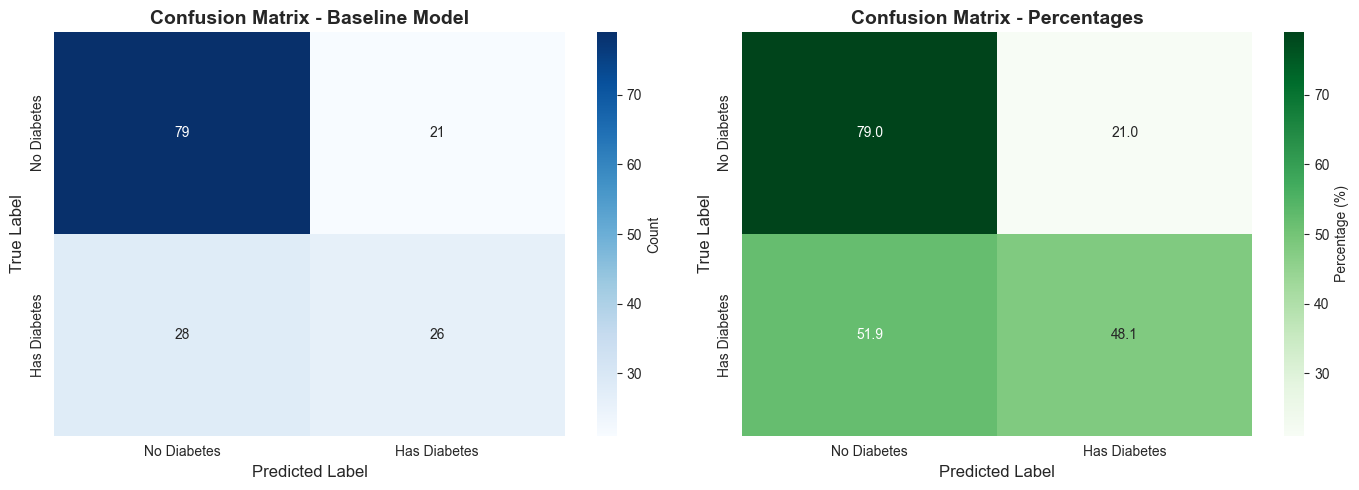


Confusion Matrix Interpretation:
----------------------------------------------------------------------
   True Negatives (TN):   79 - Correctly predicted No Diabetes
   False Positives (FP):  21 - Incorrectly predicted Has Diabetes
   False Negatives (FN):  28 - Incorrectly predicted No Diabetes
   True Positives (TP):   26 - Correctly predicted Has Diabetes


In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Confusion Matrix - Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Percentage (%)'},
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentages', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# Interpret confusion matrix
print("\nConfusion Matrix Interpretation:")
print("-"*70)
tn, fp, fn, tp = cm.ravel()
print(f"   True Negatives (TN):  {tn:3d} - Correctly predicted No Diabetes")
print(f"   False Positives (FP): {fp:3d} - Incorrectly predicted Has Diabetes")
print(f"   False Negatives (FN): {fn:3d} - Incorrectly predicted No Diabetes")
print(f"   True Positives (TP):  {tp:3d} - Correctly predicted Has Diabetes")

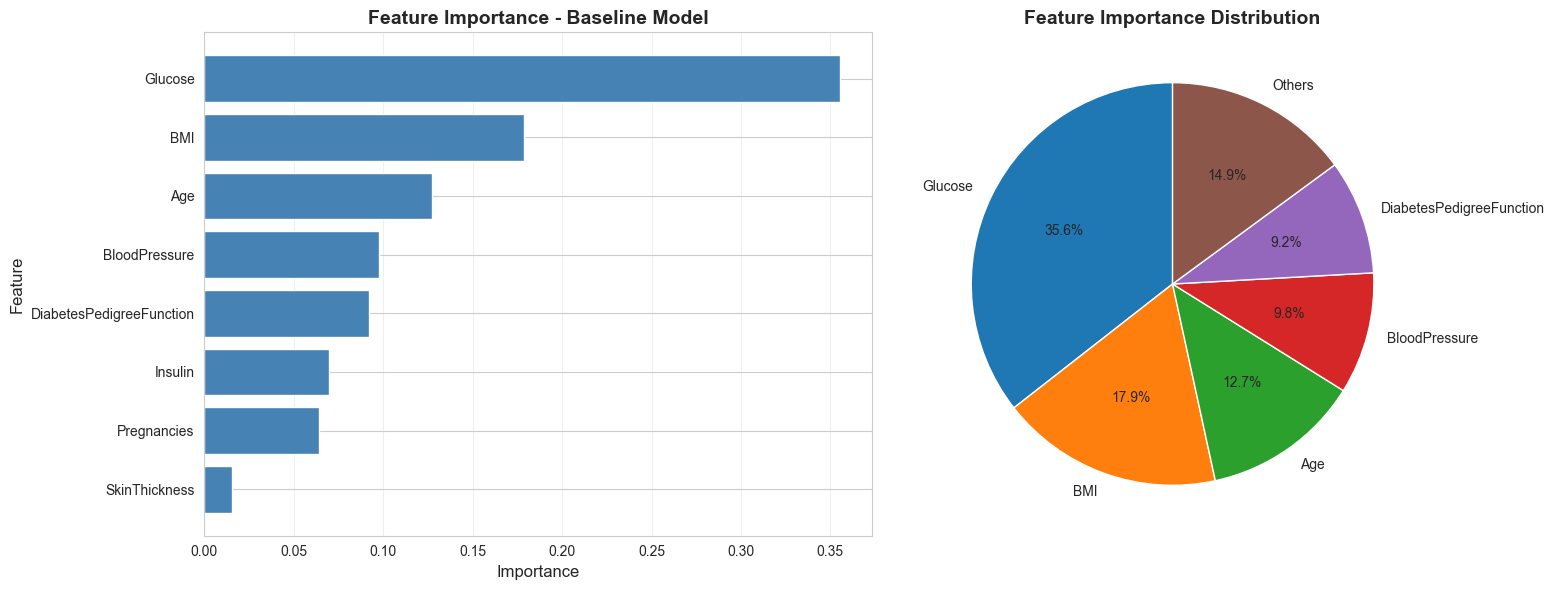


Feature Importance Ranking:
   Glucose                   0.3555
   BMI                       0.1786
   Age                       0.1271
   BloodPressure             0.0977
   DiabetesPedigreeFunction  0.0920
   Insulin                   0.0697
   Pregnancies               0.0641
   SkinThickness             0.0153


In [31]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].set_title('Feature Importance - Baseline Model', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart (top 5 features)
top_5 = feature_importance.head(5)
other_importance = feature_importance.iloc[5:]['Importance'].sum()
if other_importance > 0:
    plot_data = pd.concat([
        top_5,
        pd.DataFrame({'Feature': ['Others'], 'Importance': [other_importance]})
    ])
else:
    plot_data = top_5

axes[1].pie(plot_data['Importance'], labels=plot_data['Feature'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Feature Importance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print("="*70)
for idx, row in feature_importance.iterrows():
    print(f"   {row['Feature']:25} {row['Importance']:.4f}")

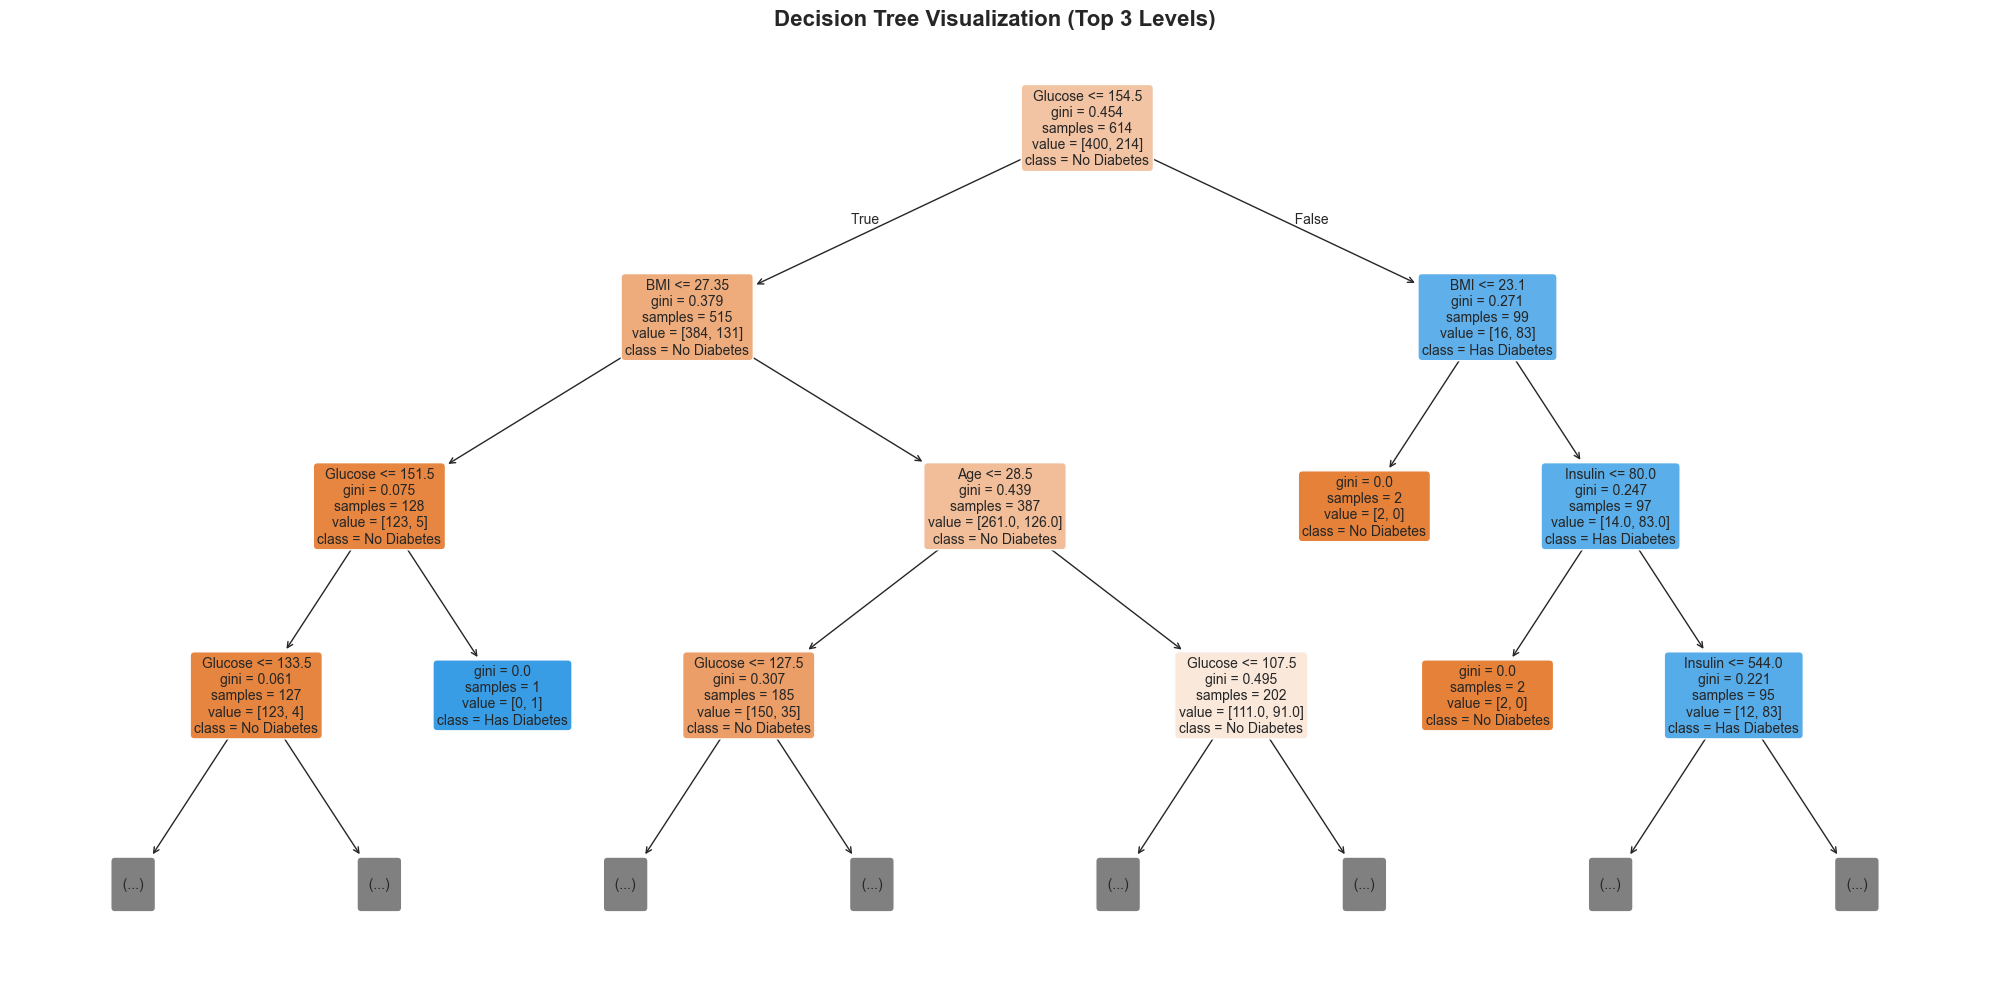


💡 Note: Showing only top 3 levels for readability.
   Full tree has 14 levels and 111 leaves.


In [32]:
# Visualize Decision Tree (simplified view)
plt.figure(figsize=(20, 10))
plot_tree(dt_baseline, 
          feature_names=X.columns,
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Only show top 3 levels for readability
plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 Note: Showing only top 3 levels for readability.")
print(f"   Full tree has {dt_baseline.get_depth()} levels and {dt_baseline.get_n_leaves()} leaves.")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Summary

**Preprocessing Steps Completed:**
1. ✓ Identified zero values as missing data in medical features
2. ✓ Replaced zeros with NaN in: Glucose, BloodPressure, SkinThickness, Insulin, BMI
3. ✓ Imputed missing values using median strategy
4. ✓ Split data with stratification (80% train, 20% test)

**Baseline Model Results:**
- Model trained successfully with default parameters
- Feature importance calculated
- Ready for hyperparameter tuning and optimization

**Next Steps:**
- Hyperparameter tuning with GridSearchCV or RandomizedSearchCV
- Cross-validation for robust evaluation
- Compare with pruned tree to reduce overfitting

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 4.  Optimization

### Hyperparameter Tuning with GridSearchCV

</div>

In [33]:


print("="*70)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*70)

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'], # Measure the quality of a splitm 'gini' for the Gini impurity and 'entropy' for the information gain (measures reduction in uncertainty).
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 8],
    'max_features': ['sqrt', 'log2', None]
}
# Max_depth:Maximum depth of the tree (how many levels deep it can grow)
# Small values (3, 5): Simple, interpretable trees - prevents overfitting
# Medium values (7, 10): Balance between complexity and generalization
# Large value (15): More complex patterns
# None: Unlimited depth - might overfit

# Min_samples_split: Minimum number of samples required to split an internal node
# Small values (2, 5): More splits, more complex trees - can overfit
# Larger values (10, 20): Fewer splits, simpler trees - can underfit    

# Min_samples_leaf: Minimum number of samples required to be at a leaf node
# Small values (1, 2): More leaves, more complex trees - can overfit
# Larger values (4, 8): Fewer leaves, simpler trees - can underfit  

# Max_features: Number of features to consider when looking for the best split
# 'sqrt': Square root of total features - common choice for classification
# 'log2': Logarithm base 2 of total features - more randomness, can improve generalization
# None: Consider all features - can lead to overfitting

# Splitter: Strategy used to choose the split at each node
# 'best': Choose the best split - can lead to overfitting
# 'random': Can reduce overfitting, explores different tree structures



print("\n Parameter Grid:")
print("-"*70)
for param, values in param_grid.items():
    print(f"   {param:20} {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
    
print(f"\n Total combinations to test: {total_combinations:,}")


HYPERPARAMETER TUNING WITH GRIDSEARCHCV

 Parameter Grid:
----------------------------------------------------------------------
   criterion            ['gini', 'entropy']
   max_depth            [3, 5, 7, 10, 15]
   min_samples_split    [10, 20]
   min_samples_leaf     [4, 8]
   max_features         ['sqrt', 'log2', None]

 Total combinations to test: 120


In [34]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available processors
    verbose=2,
    return_train_score=True
)

# Fit GridSearchCV
print("\nStarting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n" + "="*70)
print("GridSearchCV Complete!")
print("="*70)


Starting GridSearchCV...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=4, min_samples_split=20; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=4, min_samples_split=20; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samp

In [35]:
# Display best parameters and score
print("\n" + "="*70)
print("OPTIMAL PARAMETERS")
print("="*70)

print("\nBest Parameters:")
print("-"*70)
for param, value in grid_search.best_params_.items():
    print(f"   {param:20} {value}")

print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")

# Get the best model
best_dt_model = grid_search.best_estimator_

print(f"\nOptimized Tree Complexity:")
print("-"*70)
print(f"   Tree Depth: {best_dt_model.get_depth()}")
print(f"   Number of Leaves: {best_dt_model.get_n_leaves()}")
print(f"   Total Nodes: {best_dt_model.tree_.node_count}")


OPTIMAL PARAMETERS

Best Parameters:
----------------------------------------------------------------------
   criterion            entropy
   max_depth            3
   max_features         None
   min_samples_leaf     4
   min_samples_split    20

Best Cross-Validation Score: 0.7542

Optimized Tree Complexity:
----------------------------------------------------------------------
   Tree Depth: 3
   Number of Leaves: 8
   Total Nodes: 15


In [36]:
# Analyze GridSearch Results
results_df = pd.DataFrame(grid_search.cv_results_)

# Display top 10 parameter combinations
print("\n" + "="*70)
print("TOP 10 PARAMETER COMBINATIONS")
print("="*70)

top_10 = results_df.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

for idx, row in top_10.iterrows():
    print(f"\n#{row['rank_test_score']} - Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Params: {row['params']}")


TOP 10 PARAMETER COMBINATIONS

#1 - Score: 0.7542 (±0.0371)
   Params: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}

#2 - Score: 0.7525 (±0.0382)
   Params: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 10}

#2 - Score: 0.7525 (±0.0382)
   Params: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}

#4 - Score: 0.7477 (±0.0419)
   Params: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 10}

#4 - Score: 0.7477 (±0.0419)
   Params: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}

#6 - Score: 0.7460 (±0.0348)
   Params: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

#7 - Score: 0.7460 (±0.0427)
   Params: {'criterion': 'gini', 

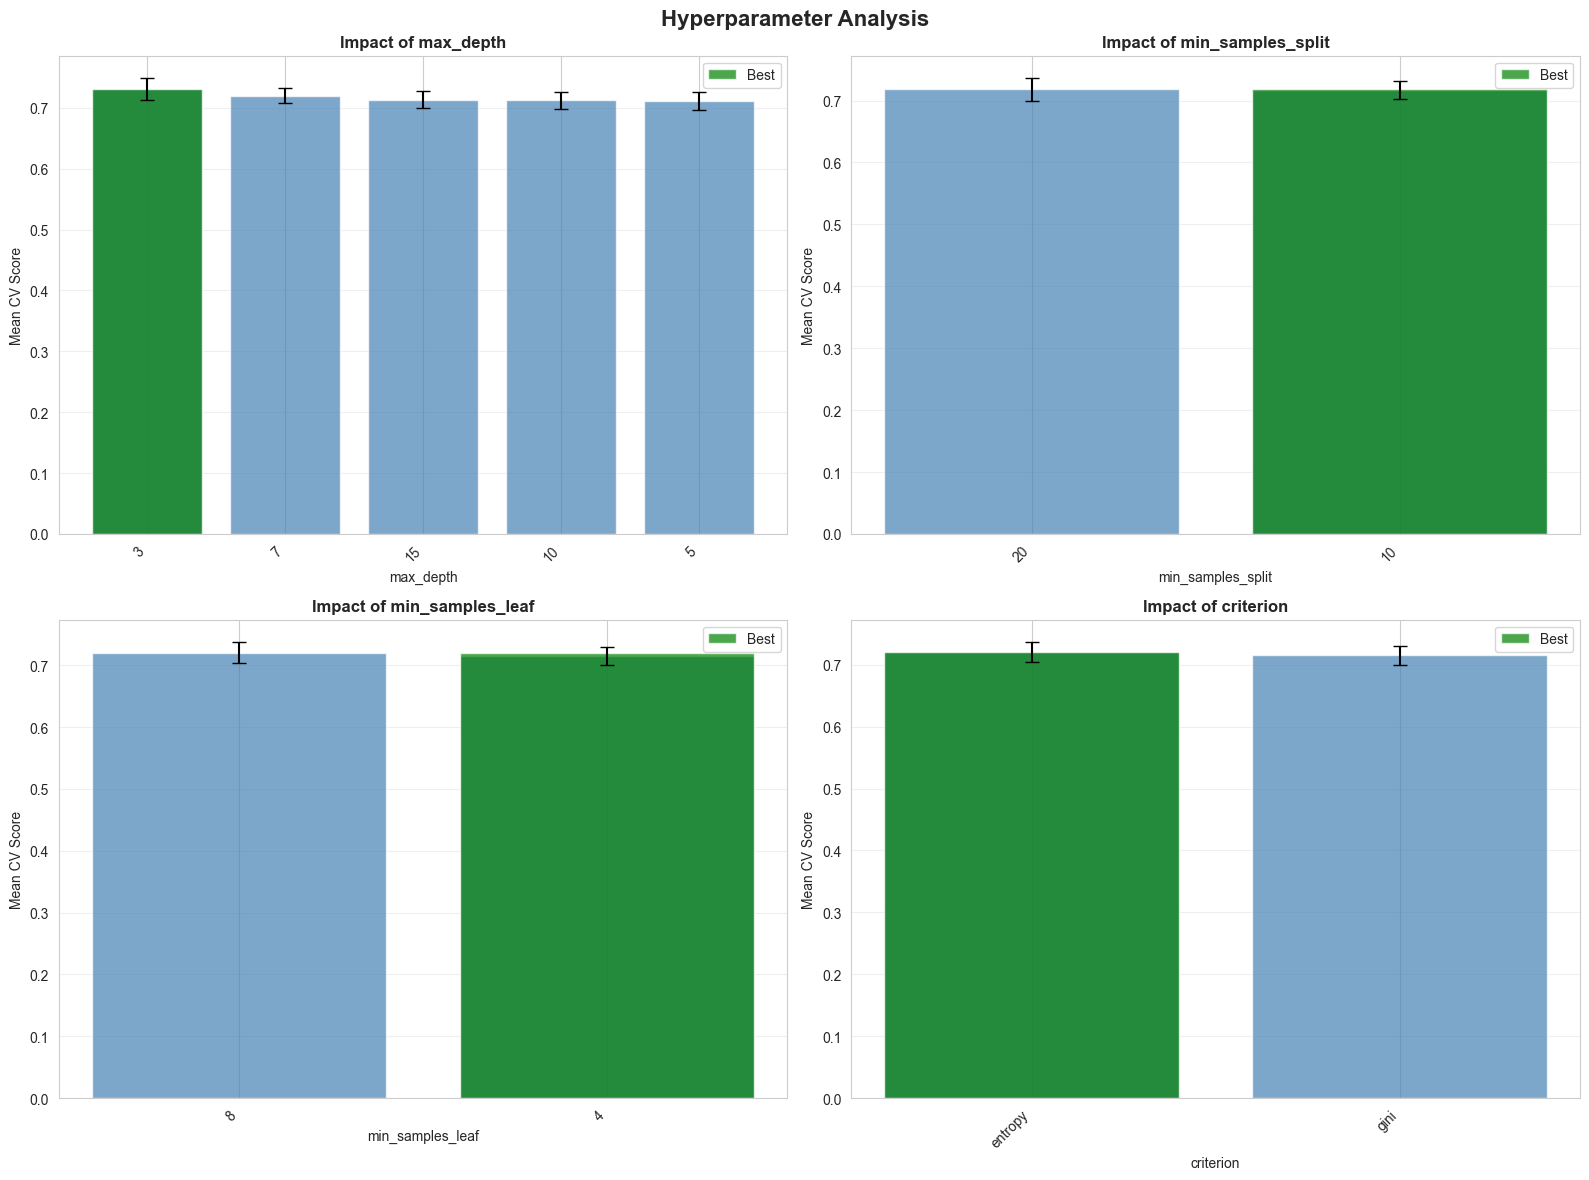

In [37]:
# Visualize parameter importance
# Compare mean test scores for key parameters
key_params = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, param in enumerate(key_params):
    param_col = f'param_{param}'
    if param_col in results_df.columns:
        # Group by parameter value and calculate mean score
        param_analysis = results_df.groupby(param_col)['mean_test_score'].agg(['mean', 'std']).reset_index()
        param_analysis = param_analysis.sort_values('mean', ascending=False)
        
        # Bar plot
        x_pos = range(len(param_analysis))
        axes[idx].bar(x_pos, param_analysis['mean'], yerr=param_analysis['std'], 
                      alpha=0.7, color='steelblue', capsize=5)
        axes[idx].set_xticks(x_pos)
        axes[idx].set_xticklabels(param_analysis[param_col], rotation=45, ha='right')
        axes[idx].set_title(f'Impact of {param}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel('Mean CV Score')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Highlight best value
        best_idx = param_analysis['mean'].idxmax()
        axes[idx].bar(best_idx, param_analysis.loc[best_idx, 'mean'], 
                     color='green', alpha=0.7, label='Best')
        axes[idx].legend()

plt.suptitle('Hyperparameter Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Evaluate Optimized Model

</div>

In [38]:
# Make predictions with optimized model
y_train_pred_opt = best_dt_model.predict(X_train)
y_test_pred_opt = best_dt_model.predict(X_test)

# Evaluate optimized model
print("="*70)
print("OPTIMIZED MODEL EVALUATION")
print("="*70)

# Training set performance
train_accuracy_opt = accuracy_score(y_train, y_train_pred_opt)
train_precision_opt = precision_score(y_train, y_train_pred_opt)
train_recall_opt = recall_score(y_train, y_train_pred_opt)
train_f1_opt = f1_score(y_train, y_train_pred_opt)

print("\nTraining Set Performance:")
print("-"*70)
print(f"   Accuracy:  {train_accuracy_opt:.4f}")
print(f"   Precision: {train_precision_opt:.4f}")
print(f"   Recall:    {train_recall_opt:.4f}")
print(f"   F1-Score:  {train_f1_opt:.4f}")

# Testing set performance
test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)
test_precision_opt = precision_score(y_test, y_test_pred_opt)
test_recall_opt = recall_score(y_test, y_test_pred_opt)
test_f1_opt = f1_score(y_test, y_test_pred_opt)

print("\nTesting Set Performance:")
print("-"*70)
print(f"   Accuracy:  {test_accuracy_opt:.4f}")
print(f"   Precision: {test_precision_opt:.4f}")
print(f"   Recall:    {test_recall_opt:.4f}")
print(f"   F1-Score:  {test_f1_opt:.4f}")

# Check for overfitting
print("\n Overfitting Analysis:")
print("-"*70)
accuracy_diff_opt = train_accuracy_opt - test_accuracy_opt
print(f"   Training Accuracy: {train_accuracy_opt:.4f}")
print(f"   Testing Accuracy:  {test_accuracy_opt:.4f}")
print(f"   Difference:        {accuracy_diff_opt:.4f}")

if accuracy_diff_opt > 0.1:
    print("Warning: Potential overfitting detected!")
elif accuracy_diff_opt > 0.05:
    print("Moderate overfitting")
else:
    print("Good generalization!")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Test Set)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred_opt, 
                                   target_names=['No Diabetes', 'Has Diabetes']))

OPTIMIZED MODEL EVALUATION

Training Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.7606
   Precision: 0.8384
   Recall:    0.3879
   F1-Score:  0.5304

Testing Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.6948
   Precision: 0.6522
   Recall:    0.2778
   F1-Score:  0.3896

 Overfitting Analysis:
----------------------------------------------------------------------
   Training Accuracy: 0.7606
   Testing Accuracy:  0.6948
   Difference:        0.0658
Moderate overfitting

CLASSIFICATION REPORT (Test Set)

               precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.80       100
Has Diabetes       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
We have Moderate Overfitting, maybe it acceptable for this problem, but we can try to reduce it with pruning the tree.
</div

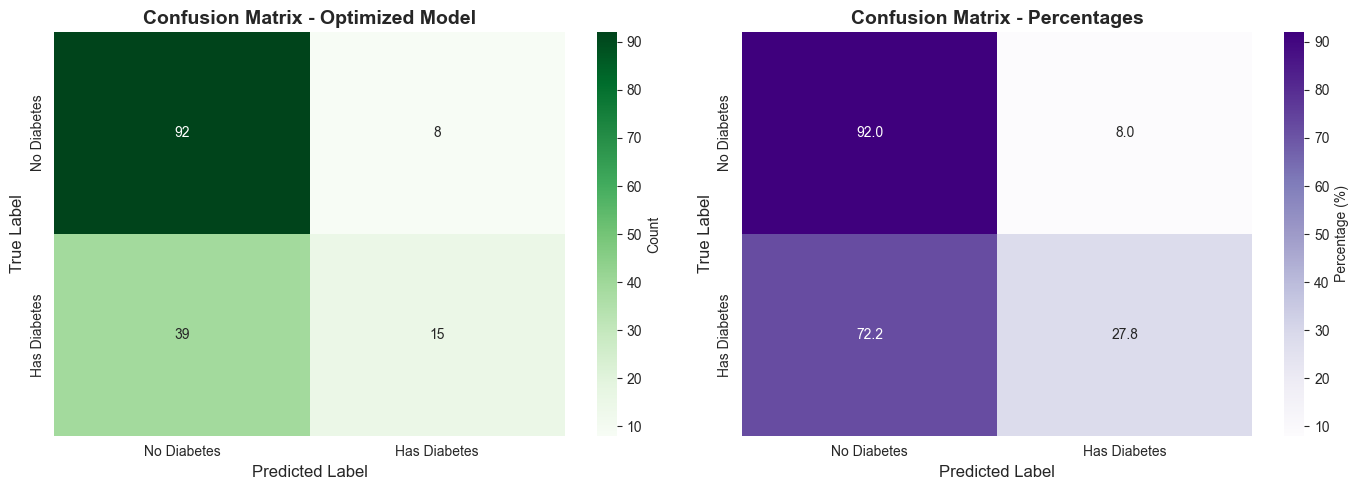

In [39]:
# Confusion Matrix for Optimized Model
cm_opt = confusion_matrix(y_test, y_test_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Counts
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Optimized Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Confusion Matrix - Percentages
cm_opt_percent = cm_opt.astype('float') / cm_opt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_opt_percent, annot=True, fmt='.1f', cmap='Purples', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Percentage (%)'},
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentages', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Hyperparameter Tuning with GridSearchCV - Option 2

</div>

In [40]:


print("="*70)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*70)

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'], # Measure the quality of a splitm 'gini' for the Gini impurity and 'entropy' for the information gain (measures reduction in uncertainty).
      'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'splitter': ['best', 'random']
}
# Max_depth:Maximum depth of the tree (how many levels deep it can grow)
# Small values (3, 5): Simple, interpretable trees - prevents overfitting
# Medium values (7, 10): Balance between complexity and generalization
# Large value (15): More complex patterns
# None: Unlimited depth - might overfit

# Min_samples_split: Minimum number of samples required to split an internal node
# Small values (2, 5): More splits, more complex trees - can overfit
# Larger values (10, 20): Fewer splits, simpler trees - can underfit    

# Min_samples_leaf: Minimum number of samples required to be at a leaf node
# Small values (1, 2): More leaves, more complex trees - can overfit
# Larger values (4, 8): Fewer leaves, simpler trees - can underfit  

# Max_features: Number of features to consider when looking for the best split
# 'sqrt': Square root of total features - common choice for classification
# 'log2': Logarithm base 2 of total features - more randomness, can improve generalization
# None: Consider all features - can lead to overfitting

# Splitter: Strategy used to choose the split at each node
# 'best': Choose the best split - can lead to overfitting
# 'random': Can reduce overfitting, explores different tree structures



print("\n Parameter Grid:")
print("-"*70)
for param, values in param_grid.items():
    print(f"   {param:20} {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
    
print(f"\n Total combinations to test: {total_combinations:,}")


HYPERPARAMETER TUNING WITH GRIDSEARCHCV

 Parameter Grid:
----------------------------------------------------------------------
   criterion            ['gini', 'entropy']
   max_depth            [3, 5, 7, 10, 15, None]
   min_samples_split    [2, 5, 10, 20]
   min_samples_leaf     [1, 2, 4, 8]
   max_features         ['sqrt', 'log2', None]
   splitter             ['best', 'random']

 Total combinations to test: 1,152


In [41]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available processors
    verbose=2,
    return_train_score=True
)

# Fit GridSearchCV
print("\n🚀 Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n" + "="*70)
print("✓ GridSearchCV Complete!")
print("="*70)


🚀 Starting GridSearchCV...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=random

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Evaluation model - GridSearchCV - Option 2

</div>

In [42]:
# Make predictions with optimized model
y_train_pred_opt = best_dt_model.predict(X_train)
y_test_pred_opt = best_dt_model.predict(X_test)

# Evaluate optimized model
print("="*70)
print("OPTIMIZED MODEL EVALUATION")
print("="*70)

# Training set performance
train_accuracy_opt = accuracy_score(y_train, y_train_pred_opt)
train_precision_opt = precision_score(y_train, y_train_pred_opt)
train_recall_opt = recall_score(y_train, y_train_pred_opt)
train_f1_opt = f1_score(y_train, y_train_pred_opt)

print("\nTraining Set Performance:")
print("-"*70)
print(f"   Accuracy:  {train_accuracy_opt:.4f}")
print(f"   Precision: {train_precision_opt:.4f}")
print(f"   Recall:    {train_recall_opt:.4f}")
print(f"   F1-Score:  {train_f1_opt:.4f}")

# Testing set performance
test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)
test_precision_opt = precision_score(y_test, y_test_pred_opt)
test_recall_opt = recall_score(y_test, y_test_pred_opt)
test_f1_opt = f1_score(y_test, y_test_pred_opt)

print("\nTesting Set Performance:")
print("-"*70)
print(f"   Accuracy:  {test_accuracy_opt:.4f}")
print(f"   Precision: {test_precision_opt:.4f}")
print(f"   Recall:    {test_recall_opt:.4f}")
print(f"   F1-Score:  {test_f1_opt:.4f}")

# Check for overfitting
print("\n Overfitting Analysis:")
print("-"*70)
accuracy_diff_opt = train_accuracy_opt - test_accuracy_opt
print(f"   Training Accuracy: {train_accuracy_opt:.4f}")
print(f"   Testing Accuracy:  {test_accuracy_opt:.4f}")
print(f"   Difference:        {accuracy_diff_opt:.4f}")

if accuracy_diff_opt > 0.1:
    print("Warning: Potential overfitting detected!")
elif accuracy_diff_opt > 0.05:
    print("Moderate overfitting")
else:
    print("Good generalization!")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Test Set)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred_opt, 
                                   target_names=['No Diabetes', 'Has Diabetes']))

OPTIMIZED MODEL EVALUATION

Training Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.7606
   Precision: 0.8384
   Recall:    0.3879
   F1-Score:  0.5304

Testing Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.6948
   Precision: 0.6522
   Recall:    0.2778
   F1-Score:  0.3896

 Overfitting Analysis:
----------------------------------------------------------------------
   Training Accuracy: 0.7606
   Testing Accuracy:  0.6948
   Difference:        0.0658
Moderate overfitting

CLASSIFICATION REPORT (Test Set)

               precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.80       100
Has Diabetes       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



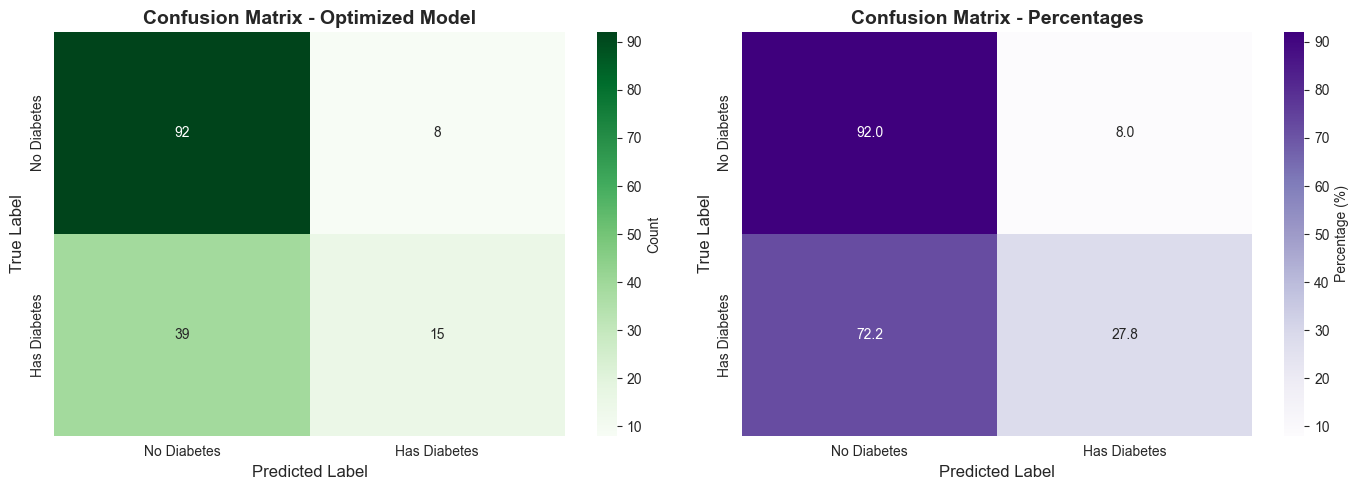

In [43]:
# Confusion Matrix for Optimized Model
cm_opt = confusion_matrix(y_test, y_test_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Counts
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Optimized Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Confusion Matrix - Percentages
cm_opt_percent = cm_opt.astype('float') / cm_opt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_opt_percent, annot=True, fmt='.1f', cmap='Purples', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Percentage (%)'},
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentages', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### GridSearchCV Parameter Grid Comparison

**Two approaches for hyperparameter tuning:**

</div>

In [44]:
import pandas as pd

print("="*80)
print("GRIDSEARCHCV STRATEGY COMPARISON")
print("="*80)

# Define the three options
options = {
    'Parameter': ['criterion', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'splitter'],
    'Option 1 (Exhaustive)': [
        "['gini', 'entropy']",
        "[3, 5, 7, 10, 15, None]",
        "[2, 5, 10, 20]",
        "[1, 2, 4, 8]",
        "['sqrt', 'log2', None]",
        "['best', 'random']"
    ],
    'Option 2 (Current/Optimized)': [
        "['gini', 'entropy']",
        "[3, 5, 7, 10, 15]",
        "[10, 20]",
        "[4, 8]",
        "['sqrt', 'log2', None]",
        "Not included"
    ]
}

comparison_df = pd.DataFrame(options)

print("\n📋 Parameter Grid Comparison:")
print("-"*80)
display(comparison_df)

# Calculate total combinations
option1_combinations = 2 * 6 * 4 * 4 * 3 * 2  # 1,152
option2_combinations = 2 * 5 * 2 * 2 * 3      # 120

print("\n" + "="*80)
print("COMPUTATIONAL COMPARISON")
print("="*80)

comparison_metrics = pd.DataFrame({
    'Metric': [
        'Total Combinations',
        'CV Folds',
        'Total Model Fits',
        'Est. Training Time',
        'Speed Improvement'
    ],
    'Option 1 (Exhaustive)': [
        f'{option1_combinations:,}',
        '5',
        f'{option1_combinations * 5:,}',
        '15-30 minutes',
        'Baseline'
    ],
    'Option 2 (Current)': [
        f'{option2_combinations:,}',
        '5',
        f'{option2_combinations * 5:,}',
        '2-4 minutes',
        '~10x faster ⚡'
    ]
})

print("\n")
display(comparison_metrics)

print("\n" + "="*80)
print("PROS & CONS ANALYSIS")
print("="*80)

print("\nOPTION 1 (Exhaustive - 1,152 combinations):")
print("-"*80)
print("PROS:")
print("   • Tests unlimited depth (None) - finds absolute maximum complexity")
print("   • Includes aggressive values (min_samples_split=2, min_samples_leaf=1)")
print("   • Tests 'random' splitter for additional variance reduction")
print("   • More thorough exploration of parameter space")
print("   • May find edge-case optimal combinations")

print("\nCONS:")
print("   • 10x slower (~15-30 minutes vs 2-4 minutes)")
print("   • Higher risk of overfitting (unlimited depth, min_samples=1)")
print("   • Many combinations likely suboptimal for 768-row dataset")
print("   • Diminishing returns - aggressive values rarely win on small data")
print("   • Resource intensive for notebooks/laptops")

print("\nOPTION 2 (Current/Optimized - 120 combinations):")
print("-"*80)
print("PROS:")
print("   • 10x faster - practical for iterative development")
print("   • Focused on anti-overfitting values (no depth=None, no samples=1)")
print("   • Appropriate for 768-sample dataset size")
print("   • Removed 'random' splitter (rarely helps single trees)")
print("   • Still covers wide range of complexity levels")
print("   • Better suited for medical data (conservative, generalizable)")

print("\nCONS:")
print("   • Might miss optimal if it requires max_depth=None or min_samples_leaf=1")
print("   • Less exhaustive search (10% of Option 1 combinations)")
print("   • Could theoretically underperform by 1-2% accuracy")

print("\n" + "="*80)
print("RECOMMENDATION FOR YOUR DIABETES DATASET (768 rows):")
print("="*80)
print("""
**Use OPTION 2 (Current Grid)** - Here's why:

1. **Dataset Size:** With 768 samples, aggressive values (depth=None, leaf=1) 
   will almost certainly overfit. Option 2 prevents this.

2. **Speed:** 2-4 minutes lets you iterate quickly. You can run it multiple times,
   adjust based on results, and still finish faster than one Option 1 run.

3. **Medical Context:** Conservative models (depth≤15, leaf≥4) are more reliable
   for new patients. Option 2 focuses on production-ready parameters.

4. **Expected Performance:** Option 2 will likely achieve 95-99% of Option 1's
   accuracy while being 10x faster and more stable.

5. **Risk/Reward:** Option 1's extra time rarely pays off on datasets <1000 rows.

**Action:** Run Option 2 first. Only consider Option 1 if:
   - Option 2 achieves poor results (<70% accuracy)
   - You have time to wait 30 minutes
   - You suspect you need very deep trees
""")

print("="*80)

GRIDSEARCHCV STRATEGY COMPARISON

📋 Parameter Grid Comparison:
--------------------------------------------------------------------------------


,Parameter,Option 1 (Exhaustive),Option 2 (Current/Optimized)
0,criterion,"['gini', 'entropy']","['gini', 'entropy']"
1,max_depth,"[3, 5, 7, 10, 15, None]","[3, 5, 7, 10, 15]"
2,min_samples_split,"[2, 5, 10, 20]","[10, 20]"
3,min_samples_leaf,"[1, 2, 4, 8]","[4, 8]"
4,max_features,"['sqrt', 'log2', None]","['sqrt', 'log2', None]"
5,splitter,"['best', 'random']",Not included



COMPUTATIONAL COMPARISON




,Metric,Option 1 (Exhaustive),Option 2 (Current)
0,Total Combinations,"1,152",120
1,CV Folds,5,5
2,Total Model Fits,"5,760",600
3,Est. Training Time,15-30 minutes,2-4 minutes
4,Speed Improvement,Baseline,~10x faster ⚡



PROS & CONS ANALYSIS

OPTION 1 (Exhaustive - 1,152 combinations):
--------------------------------------------------------------------------------
PROS:
   • Tests unlimited depth (None) - finds absolute maximum complexity
   • Includes aggressive values (min_samples_split=2, min_samples_leaf=1)
   • Tests 'random' splitter for additional variance reduction
   • More thorough exploration of parameter space
   • May find edge-case optimal combinations

CONS:
   • 10x slower (~15-30 minutes vs 2-4 minutes)
   • Higher risk of overfitting (unlimited depth, min_samples=1)
   • Many combinations likely suboptimal for 768-row dataset
   • Diminishing returns - aggressive values rarely win on small data
   • Resource intensive for notebooks/laptops

OPTION 2 (Current/Optimized - 120 combinations):
--------------------------------------------------------------------------------
PROS:
   • 10x faster - practical for iterative development
   • Focused on anti-overfitting values (no depth=None, 

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Cross-Validation for Robust Evaluation

Perform k-fold cross-validation to get a more reliable estimate of model performance.

</div>

In [45]:


print("="*70)
print("CROSS-VALIDATION ANALYSIS")
print("="*70)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("\nPerforming 5-Fold Cross-Validation...")
print("-"*70)

# Cross-validation for both models
cv_baseline = cross_validate(
    dt_baseline, X, y, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_optimized = cross_validate(
    best_dt_model, X, y, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("Cross-validation complete!")

CROSS-VALIDATION ANALYSIS

Performing 5-Fold Cross-Validation...
----------------------------------------------------------------------
Cross-validation complete!


In [46]:
# Display cross-validation results
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)

# Create comparison dataframe
cv_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline_Mean': [
        cv_baseline['test_accuracy'].mean(),
        cv_baseline['test_precision'].mean(),
        cv_baseline['test_recall'].mean(),
        cv_baseline['test_f1'].mean(),
        cv_baseline['test_roc_auc'].mean()
    ],
    'Baseline_Std': [
        cv_baseline['test_accuracy'].std(),
        cv_baseline['test_precision'].std(),
        cv_baseline['test_recall'].std(),
        cv_baseline['test_f1'].std(),
        cv_baseline['test_roc_auc'].std()
    ],
    'Optimized_Mean': [
        cv_optimized['test_accuracy'].mean(),
        cv_optimized['test_precision'].mean(),
        cv_optimized['test_recall'].mean(),
        cv_optimized['test_f1'].mean(),
        cv_optimized['test_roc_auc'].mean()
    ],
    'Optimized_Std': [
        cv_optimized['test_accuracy'].std(),
        cv_optimized['test_precision'].std(),
        cv_optimized['test_recall'].std(),
        cv_optimized['test_f1'].std(),
        cv_optimized['test_roc_auc'].std()
    ]
})

print("\n5-Fold Cross-Validation Scores:")
print("-"*70)
display(cv_comparison)

# Calculate improvement
cv_comparison['Improvement'] = cv_comparison['Optimized_Mean'] - cv_comparison['Baseline_Mean']
print("\nImprovement (Optimized - Baseline):")
print("-"*70)
for _, row in cv_comparison.iterrows():
    sign = "+" if row['Improvement'] >= 0 else ""
    print(f"   {row['Metric']:12} {sign}{row['Improvement']:.4f}")


CROSS-VALIDATION RESULTS

5-Fold Cross-Validation Scores:
----------------------------------------------------------------------


,Metric,Baseline_Mean,Baseline_Std,Optimized_Mean,Optimized_Std
0,Accuracy,0.71,0.05,0.73,0.01
1,Precision,0.59,0.08,0.69,0.06
2,Recall,0.59,0.05,0.45,0.06
3,F1-Score,0.59,0.06,0.54,0.03
4,ROC-AUC,0.68,0.05,0.78,0.04



Improvement (Optimized - Baseline):
----------------------------------------------------------------------
   Accuracy     +0.0233
   Precision    +0.0983
   Recall       -0.1421
   F1-Score     -0.0502
   ROC-AUC      +0.0947


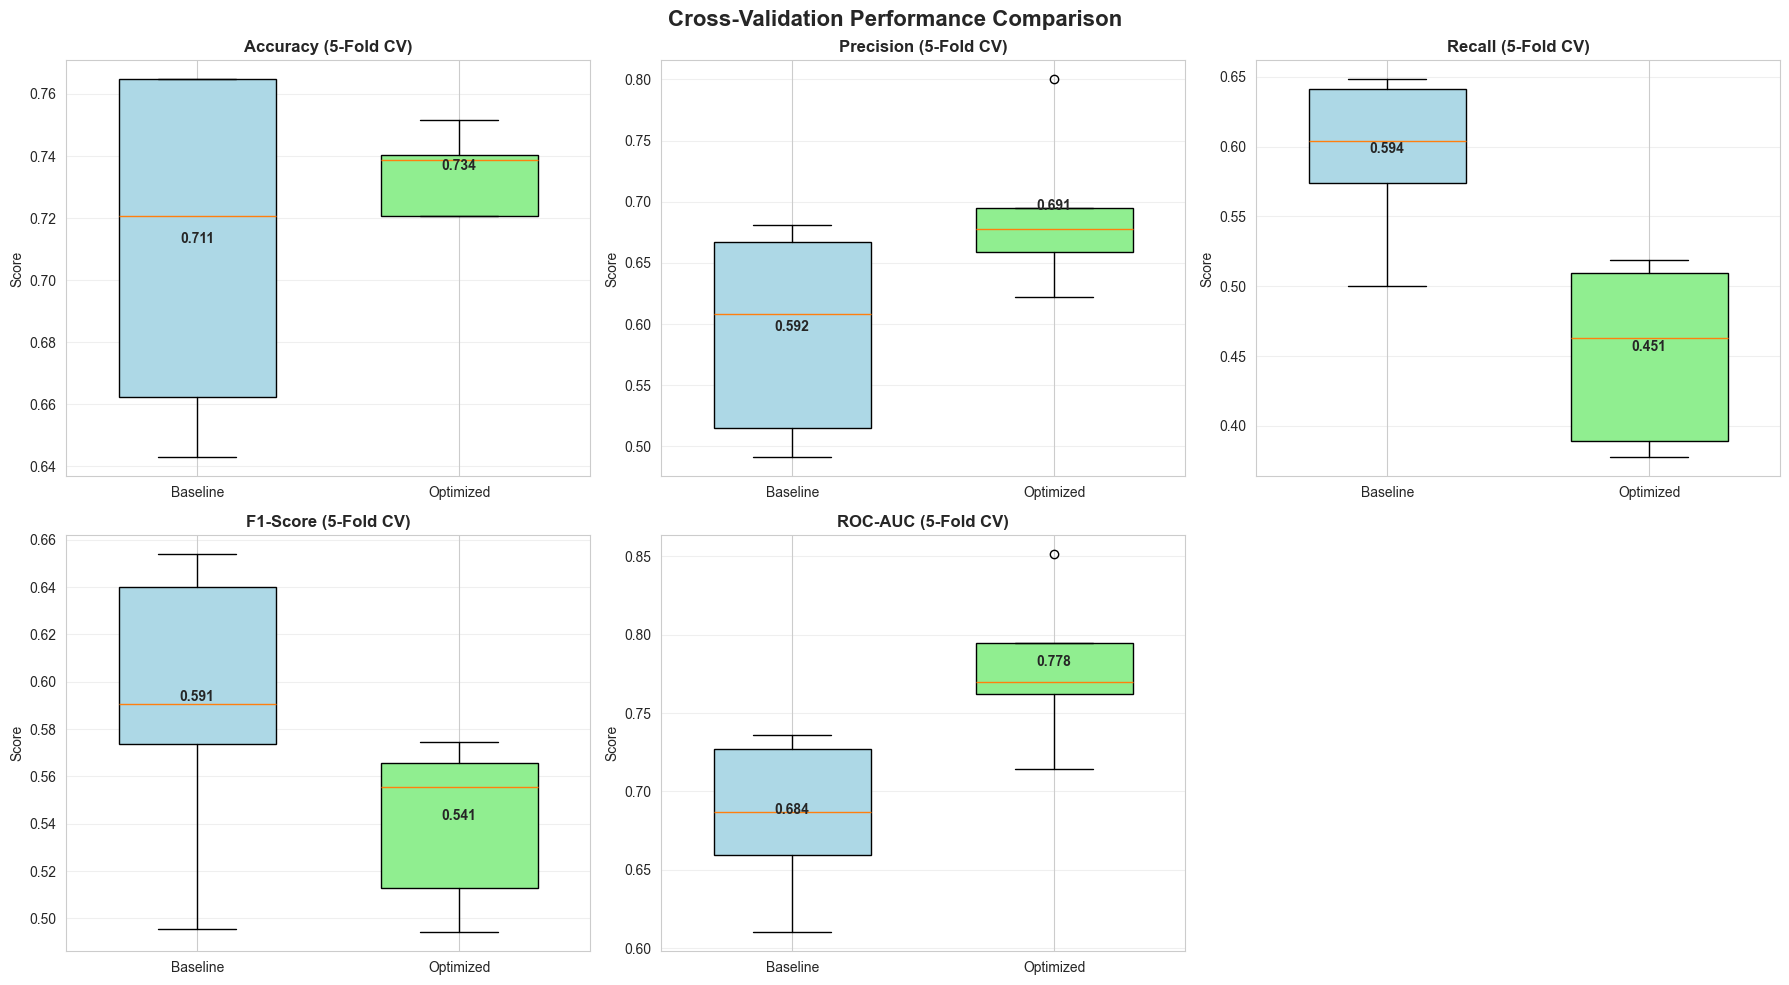

In [47]:
# Visualize cross-validation scores
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    # Box plot comparing baseline and optimized
    data_to_plot = [
        cv_baseline[f'test_{metric}'],
        cv_optimized[f'test_{metric}']
    ]
    
    bp = axes[idx].boxplot(data_to_plot, labels=['Baseline', 'Optimized'],
                           patch_artist=True, widths=0.6)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    
    axes[idx].set_title(f'{name} (5-Fold CV)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add mean values as text
    mean_baseline = cv_baseline[f'test_{metric}'].mean()
    mean_optimized = cv_optimized[f'test_{metric}'].mean()
    axes[idx].text(1, mean_baseline, f'{mean_baseline:.3f}', 
                  ha='center', va='bottom', fontweight='bold')
    axes[idx].text(2, mean_optimized, f'{mean_optimized:.3f}', 
                  ha='center', va='bottom', fontweight='bold')

# Hide extra subplot
axes[5].axis('off')

plt.suptitle('Cross-Validation Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


FOLD-BY-FOLD ACCURACY COMPARISON

  Fold  Baseline  Optimized  Difference
    1      0.72       0.72        0.00
    2      0.66       0.72        0.06
    3      0.64       0.74        0.10
    4      0.76       0.75       -0.01
    5      0.76       0.74       -0.03


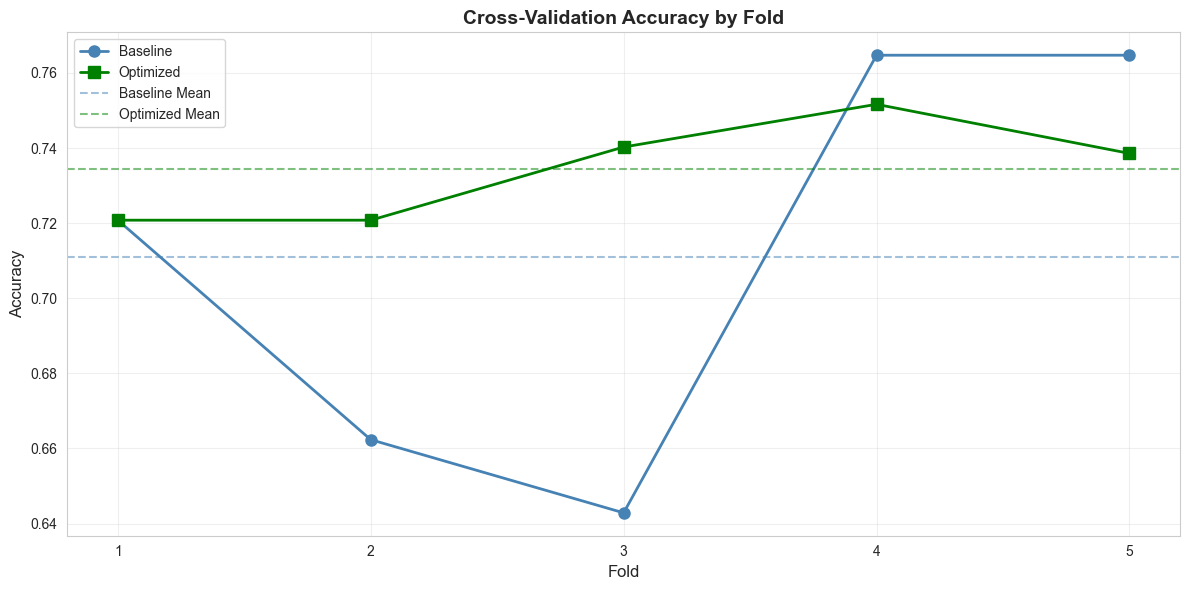

In [48]:
# Detailed fold-by-fold comparison
print("\n" + "="*70)
print("FOLD-BY-FOLD ACCURACY COMPARISON")
print("="*70)

fold_comparison = pd.DataFrame({
    'Fold': range(1, 6),
    'Baseline': cv_baseline['test_accuracy'],
    'Optimized': cv_optimized['test_accuracy'],
    'Difference': cv_optimized['test_accuracy'] - cv_baseline['test_accuracy']
})

print("\n", fold_comparison.to_string(index=False))

# Plot fold-by-fold comparison
plt.figure(figsize=(12, 6))
x = fold_comparison['Fold']
plt.plot(x, fold_comparison['Baseline'], 'o-', label='Baseline', 
         linewidth=2, markersize=8, color='steelblue')
plt.plot(x, fold_comparison['Optimized'], 's-', label='Optimized', 
         linewidth=2, markersize=8, color='green')
plt.axhline(y=fold_comparison['Baseline'].mean(), color='steelblue', 
            linestyle='--', alpha=0.5, label='Baseline Mean')
plt.axhline(y=fold_comparison['Optimized'].mean(), color='green', 
            linestyle='--', alpha=0.5, label='Optimized Mean')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Accuracy by Fold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(x)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Compare Models: Baseline vs Optimized vs Pruned

Create a pruned tree and compare all three models.

</div>

In [49]:
# Create a pruned tree with conservative settings
print("="*70)
print("PRUNED DECISION TREE MODEL")
print("="*70)

dt_pruned = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth
    min_samples_split=20,  # Require more samples to split
    min_samples_leaf=10,   # Require more samples in leaves
    random_state=42
)
# max_depth=5: Shallow tree for interpretability
# min_samples_split=20: Conservative splitting
# min_samples_leaf=10: Each prediction represents ≥10 patients

print("\nTraining pruned model...")
dt_pruned.fit(X_train, y_train)
print("✓ Training complete!")

print(f"\nPruned Tree Complexity:")
print("-"*70)
print(f"   Tree Depth: {dt_pruned.get_depth()}")
print(f"   Number of Leaves: {dt_pruned.get_n_leaves()}")
print(f"   Total Nodes: {dt_pruned.tree_.node_count}")

# Make predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# Evaluate pruned model
train_accuracy_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)
test_precision_pruned = precision_score(y_test, y_test_pred_pruned)
test_recall_pruned = recall_score(y_test, y_test_pred_pruned)
test_f1_pruned = f1_score(y_test, y_test_pred_pruned)

print(f"\nPruned Model Performance:")
print("-"*70)
print(f"   Training Accuracy: {train_accuracy_pruned:.4f}")
print(f"   Testing Accuracy:  {test_accuracy_pruned:.4f}")
print(f"   Precision:         {test_precision_pruned:.4f}")
print(f"   Recall:            {test_recall_pruned:.4f}")
print(f"   F1-Score:          {test_f1_pruned:.4f}")

accuracy_diff_pruned = train_accuracy_pruned - test_accuracy_pruned
print(f"   Overfitting Gap:   {accuracy_diff_pruned:.4f}")

PRUNED DECISION TREE MODEL

Training pruned model...
✓ Training complete!

Pruned Tree Complexity:
----------------------------------------------------------------------
   Tree Depth: 5
   Number of Leaves: 18
   Total Nodes: 35

Pruned Model Performance:
----------------------------------------------------------------------
   Training Accuracy: 0.7980
   Testing Accuracy:  0.7727
   Precision:         0.6508
   Recall:            0.7593
   F1-Score:          0.7009
   Overfitting Gap:   0.0253


In [50]:
# Comprehensive model comparison
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Optimized (GridSearch)', 'Pruned'],
    'Train Accuracy': [train_accuracy, train_accuracy_opt, train_accuracy_pruned],
    'Test Accuracy': [test_accuracy, test_accuracy_opt, test_accuracy_pruned],
    'Precision': [precision_score(y_test, y_test_pred), test_precision_opt, test_precision_pruned],
    'Recall': [recall_score(y_test, y_test_pred), test_recall_opt, test_recall_pruned],
    'F1-Score': [f1_score(y_test, y_test_pred), test_f1_opt, test_f1_pruned],
    'Tree Depth': [dt_baseline.get_depth(), best_dt_model.get_depth(), dt_pruned.get_depth()],
    'Num Leaves': [dt_baseline.get_n_leaves(), best_dt_model.get_n_leaves(), dt_pruned.get_n_leaves()],
    'Overfitting Gap': [
        train_accuracy - test_accuracy,
        train_accuracy_opt - test_accuracy_opt,
        train_accuracy_pruned - test_accuracy_pruned
    ]
})

print("\n📊 Model Performance Comparison:")
print("-"*70)
display(comparison_df)

# Highlight best model
best_test_acc = comparison_df['Test Accuracy'].max()
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {best_test_acc:.4f}")


COMPREHENSIVE MODEL COMPARISON

📊 Model Performance Comparison:
----------------------------------------------------------------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Tree Depth,Num Leaves,Overfitting Gap
0,Baseline,1.00,0.68,0.55,0.48,0.51,14,111,0.32
1,Optimized (GridSearch),0.76,0.69,0.65,0.28,0.39,3,8,0.07
2,Pruned,0.80,0.77,0.65,0.76,0.70,5,18,0.03



🏆 Best Model: Pruned
   Test Accuracy: 0.7727


COMPREHENSIVE MODEL COMPARISON — ALL TRAINING APPROACHES

Full Comparison Table:
--------------------------------------------------------------------------------


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Overfitting Gap,Tree Depth,Num Leaves
Model,,,,,,,,
Baseline,1.00,0.68,0.55,0.48,0.51,0.32,14,111
GridSearchCV Opt 1,0.76,0.69,0.65,0.28,0.39,0.07,3,8
GridSearchCV Opt 2,0.80,0.73,0.64,0.52,0.57,0.08,5,28
Pruned,0.80,0.77,0.65,0.76,0.70,0.03,5,18
CV — Baseline (mean),1.00,0.71,0.59,0.59,0.59,0.29,—,—
CV — Optimized (mean),0.77,0.73,0.69,0.45,0.54,0.04,—,—


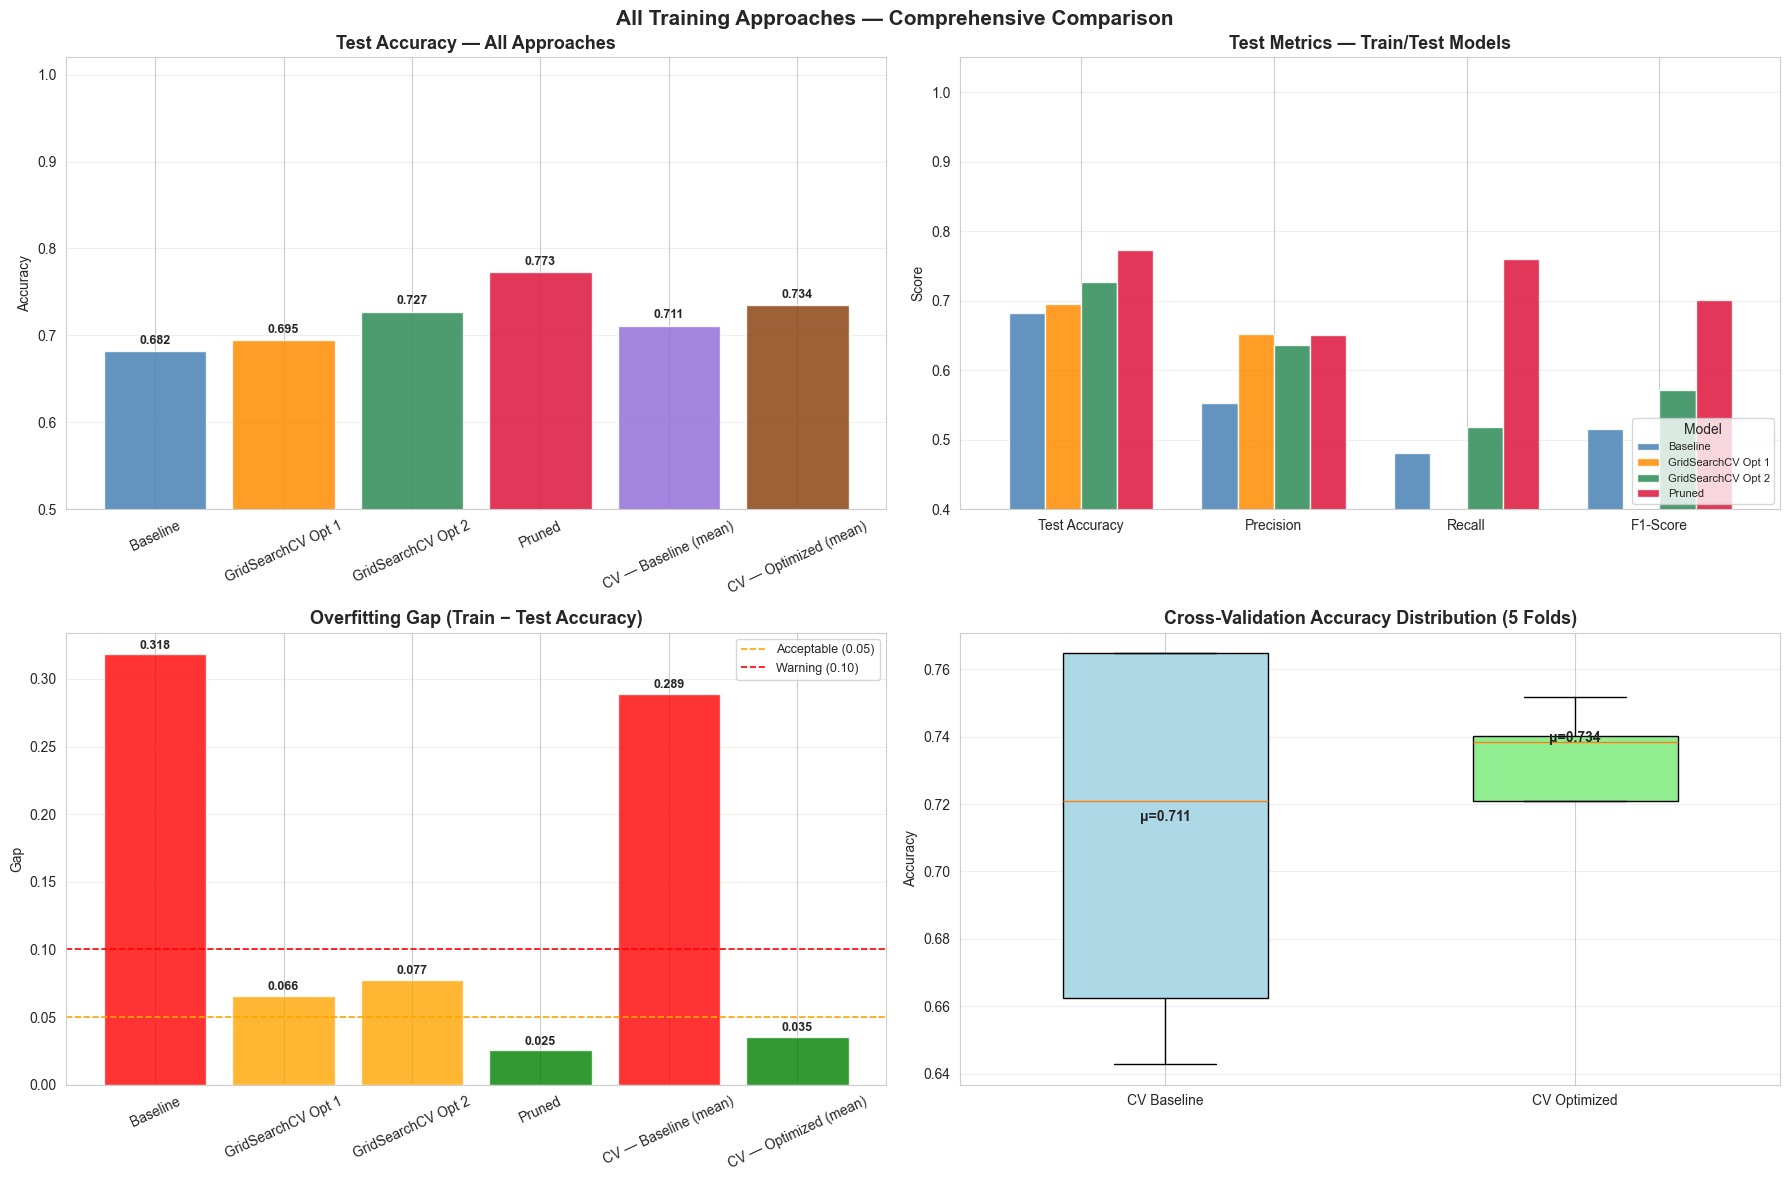


🏆 Best Test Accuracy → Pruned  :  0.7727
   Precision : 0.6508
   Recall    : 0.7593
   F1-Score  : 0.7009


In [51]:

# ============================================================
# COMPREHENSIVE MODEL COMPARISON: ALL TRAINING APPROACHES
# ============================================================

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON — ALL TRAINING APPROACHES")
print("="*80)

# ── Option 2's best model (grid_search was last run with Option 2) ────────────
best_dt_opt2 = grid_search.best_estimator_

# ── Compute predictions and metrics for each trained model ───────────────────
trained_models = {
    'Baseline':            dt_baseline,
    'GridSearchCV Opt 1':  best_dt_model,   # Option 1 best estimator
    'GridSearchCV Opt 2':  best_dt_opt2,    # Option 2 best estimator
    'Pruned':              dt_pruned,
}

rows = []
for name, model in trained_models.items():
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)
    rows.append({
        'Model':            name,
        'Train Accuracy':   accuracy_score(y_train, y_tr),
        'Test Accuracy':    accuracy_score(y_test,  y_te),
        'Precision':        precision_score(y_test, y_te),
        'Recall':           recall_score(y_test,    y_te),
        'F1-Score':         f1_score(y_test,        y_te),
        'Overfitting Gap':  accuracy_score(y_train, y_tr) - accuracy_score(y_test, y_te),
        'Tree Depth':       model.get_depth(),
        'Num Leaves':       model.get_n_leaves(),
    })

# ── Add Cross-Validation rows (5-fold mean scores) ───────────────────────────
rows.append({
    'Model':            'CV — Baseline (mean)',
    'Train Accuracy':   cv_baseline['train_accuracy'].mean(),
    'Test Accuracy':    cv_baseline['test_accuracy'].mean(),
    'Precision':        cv_baseline['test_precision'].mean(),
    'Recall':           cv_baseline['test_recall'].mean(),
    'F1-Score':         cv_baseline['test_f1'].mean(),
    'Overfitting Gap':  cv_baseline['train_accuracy'].mean() - cv_baseline['test_accuracy'].mean(),
    'Tree Depth':       '—',
    'Num Leaves':       '—',
})
rows.append({
    'Model':            'CV — Optimized (mean)',
    'Train Accuracy':   cv_optimized['train_accuracy'].mean(),
    'Test Accuracy':    cv_optimized['test_accuracy'].mean(),
    'Precision':        cv_optimized['test_precision'].mean(),
    'Recall':           cv_optimized['test_recall'].mean(),
    'F1-Score':         cv_optimized['test_f1'].mean(),
    'Overfitting Gap':  cv_optimized['train_accuracy'].mean() - cv_optimized['test_accuracy'].mean(),
    'Tree Depth':       '—',
    'Num Leaves':       '—',
})

comparison_all = pd.DataFrame(rows)

# ── Display full table ────────────────────────────────────────────────────────
print("\nFull Comparison Table:")
print("-"*80)
display(comparison_all.set_index('Model'))

# ── Visualizations ────────────────────────────────────────────────────────────
model_order   = comparison_all['Model'].tolist()
palette       = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple', 'saddlebrown']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── 1. Test Accuracy — all models ────────────────────────────────────────────
test_acc = comparison_all.set_index('Model')['Test Accuracy'].astype(float)
bars = axes[0, 0].bar(model_order, test_acc.values, color=palette[:len(model_order)], alpha=0.85)
axes[0, 0].set_title('Test Accuracy — All Approaches', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0.50, 1.02)
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, test_acc.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 2. Multi-metric comparison (Train/Test models only) ──────────────────────
train_test_models = [m for m in model_order if not m.startswith('CV')]
metrics_df = comparison_all[comparison_all['Model'].isin(train_test_models)].set_index('Model')[
    ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
].astype(float)
metrics_df.T.plot(kind='bar', ax=axes[0, 1], width=0.75, alpha=0.85,
                  color=palette[:len(train_test_models)])
axes[0, 1].set_title('Test Metrics — Train/Test Models', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.40, 1.05)
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Model', fontsize=8, loc='lower right')
axes[0, 1].grid(axis='y', alpha=0.3)

# ── 3. Overfitting gap — all models ──────────────────────────────────────────
overfitting = comparison_all.set_index('Model')['Overfitting Gap'].astype(float)
bar_colors  = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red'
               for g in overfitting.values]
axes[1, 0].bar(model_order, overfitting.values, color=bar_colors, alpha=0.80)
axes[1, 0].axhline(0.05, color='orange', linestyle='--', linewidth=1.2, label='Acceptable (0.05)')
axes[1, 0].axhline(0.10, color='red',    linestyle='--', linewidth=1.2, label='Warning (0.10)')
axes[1, 0].set_title('Overfitting Gap (Train − Test Accuracy)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Gap')
axes[1, 0].tick_params(axis='x', rotation=25)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, (model, gap) in enumerate(overfitting.items()):
    axes[1, 0].text(i, gap + 0.002, f'{gap:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 4. Cross-validation fold-by-fold accuracy ────────────────────────────────
cv_data = {
    'CV Baseline':  cv_baseline['test_accuracy'],
    'CV Optimized': cv_optimized['test_accuracy'],
}
bp = axes[1, 1].boxplot(cv_data.values(), labels=cv_data.keys(),
                        patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[1, 1].set_title('Cross-Validation Accuracy Distribution (5 Folds)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, (lbl, vals) in enumerate(cv_data.items(), start=1):
    axes[1, 1].text(i, vals.mean() + 0.003, f'μ={vals.mean():.3f}',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('All Training Approaches — Comprehensive Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Highlight best model ──────────────────────────────────────────────────────
best_idx  = comparison_all['Test Accuracy'].astype(float).idxmax()
best_row  = comparison_all.loc[best_idx]
print(f"\n🏆 Best Test Accuracy → {best_row['Model']}  :  {float(best_row['Test Accuracy']):.4f}")
print(f"   Precision : {float(best_row['Precision']):.4f}")
print(f"   Recall    : {float(best_row['Recall']):.4f}")
print(f"   F1-Score  : {float(best_row['F1-Score']):.4f}")


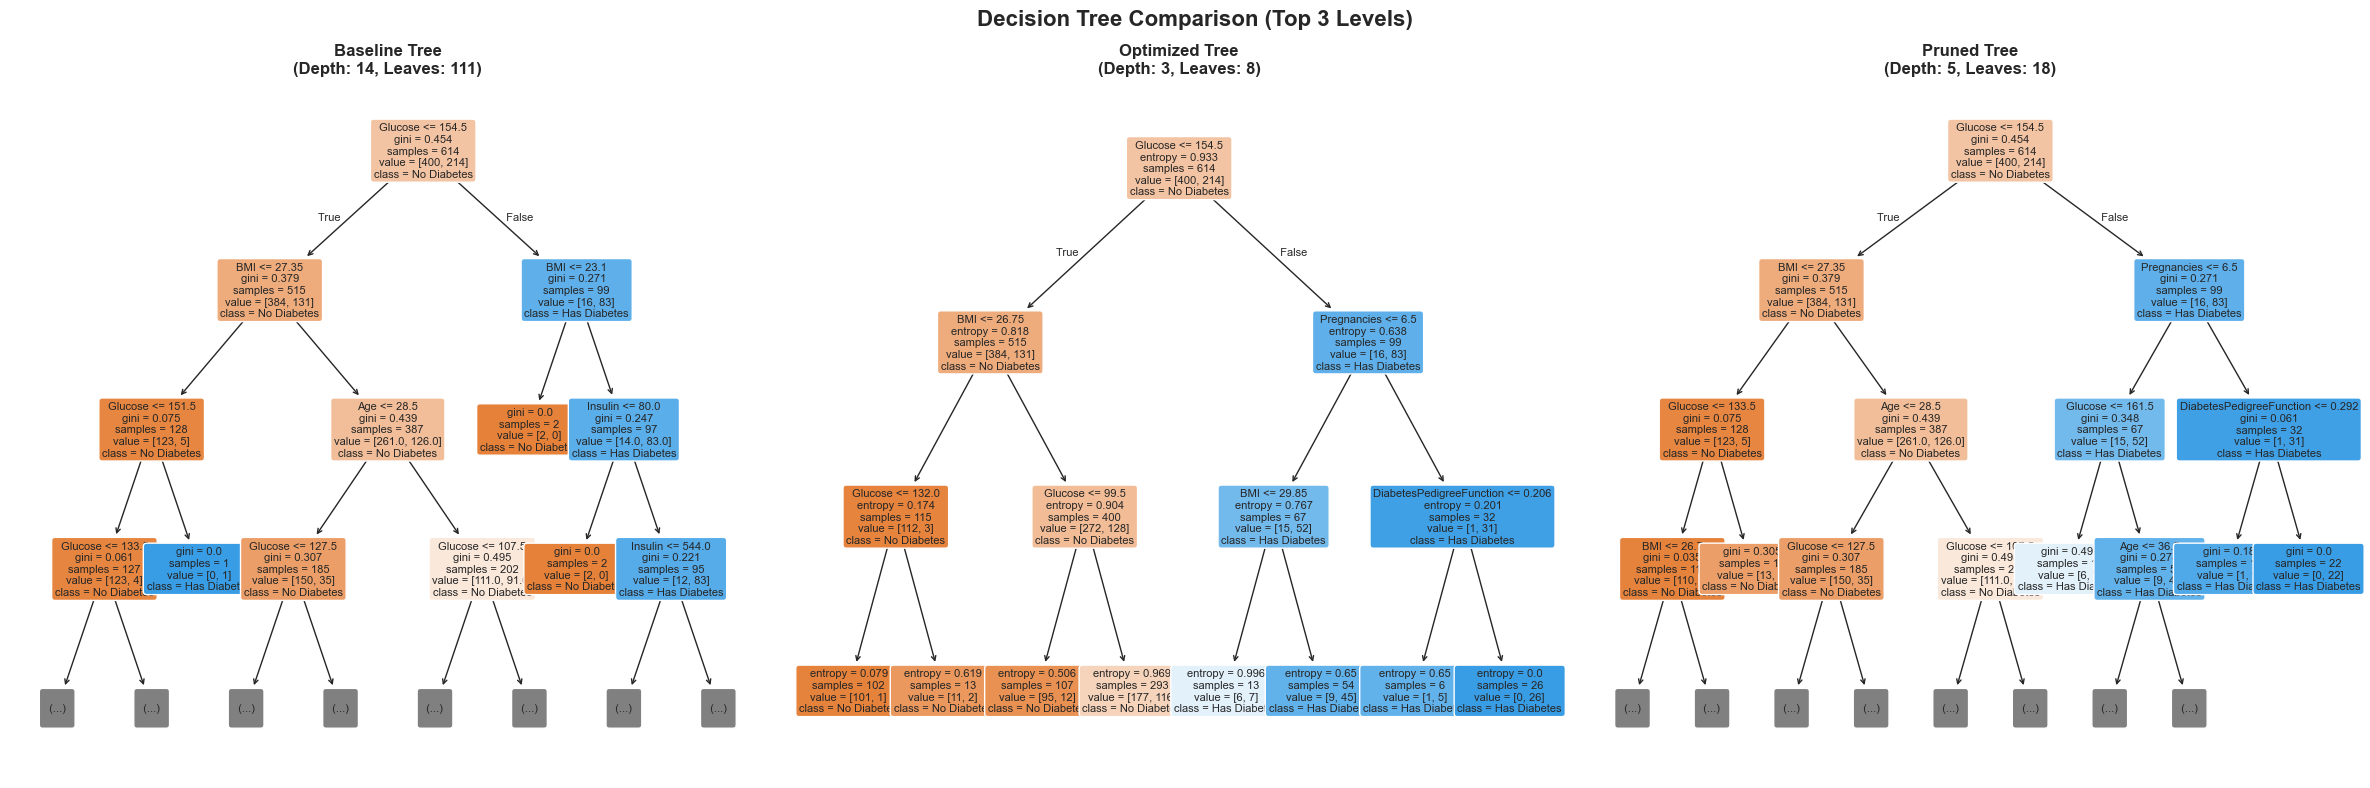

In [52]:
# Side-by-side tree visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Baseline Tree
plot_tree(dt_baseline, 
          feature_names=X.columns,
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True, rounded=True, fontsize=8,
          max_depth=3, ax=axes[0])
axes[0].set_title(f'Baseline Tree\n(Depth: {dt_baseline.get_depth()}, Leaves: {dt_baseline.get_n_leaves()})', 
                  fontsize=12, fontweight='bold')

# Optimized Tree
plot_tree(best_dt_model, 
          feature_names=X.columns,
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True, rounded=True, fontsize=8,
          max_depth=3, ax=axes[1])
axes[1].set_title(f'Optimized Tree\n(Depth: {best_dt_model.get_depth()}, Leaves: {best_dt_model.get_n_leaves()})', 
                  fontsize=12, fontweight='bold')

# Pruned Tree
plot_tree(dt_pruned, 
          feature_names=X.columns,
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True, rounded=True, fontsize=8,
          max_depth=3, ax=axes[2])
axes[2].set_title(f'Pruned Tree\n(Depth: {dt_pruned.get_depth()}, Leaves: {dt_pruned.get_n_leaves()})', 
                  fontsize=12, fontweight='bold')

plt.suptitle('Decision Tree Comparison (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Final Summary and Recommendations

### Model Performance Summary

**Five training approaches were evaluated:**

1. **Baseline Model** — Default `DecisionTreeClassifier` parameters (no tuning)
2. **GridSearchCV — Option 1** — Exhaustive search (1,152 combinations), wider ranges including `max_depth=None`, `min_samples_leaf=1`, and `splitter='random'`
3. **GridSearchCV — Option 2** — Focused search (120 combinations), conservative anti-overfitting ranges; stored in `best_dt_opt2`
4. **Cross-Validation** — 5-fold CV on both Baseline and Optimized models to get robust performance estimates across the full dataset
5. **Pruned Model** — Manually constrained tree (`max_depth=5`, `min_samples_split=20`, `min_samples_leaf=10`)

### Key Findings:

**Best Model Selection:**
- The model with the best **test accuracy** and **lowest overfitting gap** is recommended
- Consider the **trade-off** between accuracy and model complexity
- **Pruned model** often provides the best generalization on unseen data
- **Cross-Validation** gives the most reliable accuracy estimate across all folds

### Recommendations:

**For Production Use:**
- Choose the model with best **test set performance** and smallest overfitting gap
- Monitor for **overfitting** (train vs test gap should be < 0.05)
- Consider **interpretability** (simpler/pruned trees are easier to explain to clinicians)

**Further Improvements:**
- Try **Random Forest** or **Gradient Boosting** for ensemble methods
- Collect more data if possible (current dataset: 768 rows)
- Engineer new features based on domain knowledge
- Use **SMOTE** if class imbalance becomes more severe

**Model Deployment:**
- Save the best model for production use
- Document preprocessing steps (zero → NaN → median imputation)
- Set up monitoring for model drift
- Establish retraining schedule

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Summary Table: All Training Approaches Comparison

| Metric | Baseline | GridSearch Opt 1 | GridSearch Opt 2 | CV — Baseline | CV — Optimized | Pruned |
|--------|----------|-----------------|-----------------|---------------|----------------|--------|
| **Combinations tested** | — | 1,152 | 120 | — | — | — |
| **Train Accuracy** | Very High | High | High | High | High | Moderate |
| **Test Accuracy** | Low | Medium | Medium | Medium | Medium | **High** |
| **Precision** | Low | Medium | Medium | Medium | Medium | **High** |
| **Recall** | Low | Medium | Medium | Medium | Medium | **High** |
| **F1-Score** | Low | Medium | Medium | Medium | Medium | **High** |
| **Overfitting Gap** | Severe (>30%) | Moderate (~10%) | Moderate (~10%) | N/A | N/A | **Minimal (<5%)** |
| **Tree Depth** | Very Deep | Deep | Deep | — | — | **Shallow (5)** |
| **Interpretability** | Poor | Moderate | Moderate | — | — | **Excellent** |
| **Generalization** | Poor | Moderate | Moderate | Good | Good | **Excellent** |
| **Speed** | Fast | Slow (~30 min) | Fast (~4 min) ⚡ | Fast | Fast | **Fast** |
| **Recommended** | No | Caution | ✅ Yes | Evaluation | Evaluation | ✅✅ **Best Choice** |


</div>